# Synthetic Data Evaluation — Bayesian Shrinkage Priors

**Objective**: Systematically benchmark all Bayesian and Frequentist regression models across ten synthetic simulation scenarios with known ground truth, enabling direct evaluation of coefficient estimation, support recovery, and prediction accuracy.

**Models** (9 total):

- **Frequentist** (4): OLS, Lasso CV, Ridge CV, ElasticNet CV — all with feature prescreening for fair comparison
- **Bayesian** (5): Bayesian Ridge, Bayesian Lasso, Bayesian ElasticNet, Horseshoe, Spike-and-Slab

**Scenarios** (10): True Sparse, Correlated Groups, Dense Signal, Weak Signal, Ultra High-Dim, Block Correlation, Heavy-Tailed Noise, Heteroskedastic, Non-Gaussian X, Structured Sparsity

**Metrics**: RMSE, MAE, R², Adj. R², Beta-RMSE, TPR, FPR, F1, Sparsity, LOO-CV, Computation Time


In [1]:
# ============================================================
# Cell 1 — Imports & Configuration
# ============================================================

import os, sys, time, warnings, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist
from scipy.stats import invgamma, invgauss

from sklearn.linear_model import (LinearRegression, LassoCV, RidgeCV,
                                  ElasticNetCV, BayesianRidge as SklearnBayesianRidge)
from sklearn.model_selection import train_test_split, LeaveOneOut, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

import pymc as pm
import arviz as az
import pytensor.tensor as pt

warnings.filterwarnings('ignore')
logging.getLogger('pymc').setLevel(logging.CRITICAL)
logging.getLogger('pytensor').setLevel(logging.CRITICAL)
sns.set_style('whitegrid')
plt.rcParams.update({
    'figure.dpi': 120, 'figure.figsize': (14, 6),
    'font.size': 11, 'axes.titlesize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.dpi': 150,
})

# -- Global configuration --
SEED         = 42
N_ITER       = 10_000
BURN_IN      = 5_000
CI_ALPHA     = 0.05
TEST_SIZE    = 0.20
ZERO_THRESH  = 0.01
DATA_DIR     = '../synthetic_data/'
RESULTS_DIR  = 'synthetic_eval_results'
PRESCREEN_MULT = 5

# -- MCMC / VI tuning --
NUTS_DRAWS     = 4000
NUTS_TUNE      = 2000
NUTS_CHAINS    = 4
NUTS_ACCEPT    = 0.95
ADVI_ITER      = 100_000
ADVI_P_THRESH  = 250

np.random.seed(SEED)
os.makedirs(RESULTS_DIR, exist_ok=True)

# -- 9 target models --
TARGET_MODELS = [
    'OLS', 'Lasso (CV)', 'Ridge (CV)', 'ElasticNet (CV)',
    'Bayesian Ridge', 'Bayesian Lasso', 'Bayesian ElasticNet',
    'Horseshoe', 'Spike-and-Slab',
]
FREQ_MODELS = TARGET_MODELS[:4]
BAYES_MODELS = TARGET_MODELS[4:]

SCENARIO_ORDER = [
    'True Sparse', 'Correlated Groups', 'Dense Signal', 'Weak Signal',
    'Ultra High-Dim', 'Block Correlation', 'Heavy-Tailed Noise',
    'Heteroskedastic', 'Non-Gaussian X', 'Structured Sparsity',
]

SCENARIO_FILES = {
    'True Sparse':         'true_sparse.npz',
    'Correlated Groups':   'correlated_groups.npz',
    'Dense Signal':        'dense_signal.npz',
    'Weak Signal':         'weak_signal.npz',
    'Ultra High-Dim':      'ultra_high_dim.npz',
    'Block Correlation':   'block_correlation.npz',
    'Heavy-Tailed Noise':  'heavy_tailed_noise.npz',
    'Heteroskedastic':     'heteroskedastic.npz',
    'Non-Gaussian X':      'non_gaussian_x.npz',
    'Structured Sparsity': 'structured_sparsity.npz',
}

SCENARIO_COLORS = {
    'True Sparse': '#1f77b4', 'Correlated Groups': '#ff7f0e',
    'Dense Signal': '#2ca02c', 'Weak Signal': '#d62728',
    'Ultra High-Dim': '#9467bd', 'Block Correlation': '#8c564b',
    'Heavy-Tailed Noise': '#e377c2', 'Heteroskedastic': '#7f7f7f',
    'Non-Gaussian X': '#bcbd22', 'Structured Sparsity': '#17becf',
}

print(f'Configuration: SEED={SEED}, TEST_SIZE={TEST_SIZE}')
print(f'  NUTS: {NUTS_CHAINS} chains x {NUTS_DRAWS} draws, {NUTS_TUNE} tune, accept={NUTS_ACCEPT}')
print(f'  ADVI: {ADVI_ITER:,} iterations (when p > {ADVI_P_THRESH})')
print(f'  Prescreening: top {PRESCREEN_MULT}xn features for p >> n')
print(f'  Data dir: {os.path.abspath(DATA_DIR)}')
print(f'  Output dir: {os.path.abspath(RESULTS_DIR)}')
print(f'  PyMC {pm.__version__}, ArviZ {az.__version__}')
print('Imports complete ')


Configuration: SEED=42, TEST_SIZE=0.2
  NUTS: 4 chains x 4000 draws, 2000 tune, accept=0.95
  ADVI: 100,000 iterations (when p > 250)
  Prescreening: top 5xn features for p >> n
  Data dir: d:\Bayesian Regresion\Lasso\synthetic_data
  Output dir: d:\Bayesian Regresion\Lasso\Evaluation_Notebooks\synthetic_eval_results
  PyMC 5.25.1, ArviZ 0.23.4
Imports complete 


## Section 2 — Model Definitions

All 9 models from `real_world_evaluation.ipynb`: 4 frequentist (with prescreening) + 5 Bayesian (PyMC NUTS/ADVI).
Non-centered parameterizations for all Bayesian models. ADVI for p > 250 after prescreening.


In [2]:
# ============================================================
# Cell 2 — Utility Functions & All Model Class Definitions
# ============================================================

# ──── Utility Functions ────

def count_near_zero(coef, threshold=1e-3):
    """Count coefficients effectively zero."""
    return int(np.sum(np.abs(coef) < threshold))

def prescreen_features(X, y, max_features):
    """Select top features by absolute marginal correlation with y."""
    n, p = X.shape
    if p <= max_features:
        return X, np.arange(p)
    corrs = np.abs(np.array([np.corrcoef(X[:, j], y)[0, 1] for j in range(p)]))
    corrs = np.nan_to_num(corrs, 0.0)
    top_idx = np.argsort(corrs)[-max_features:]
    top_idx = np.sort(top_idx)
    return X[:, top_idx], top_idx

def map_coefs_back(coef_screened, selected_idx, p_full):
    """Map screened coefficients back to full-dimensional space."""
    coef_full = np.zeros(p_full)
    coef_full[selected_idx] = coef_screened
    return coef_full

def map_beta_samples_back(beta_samples, selected_idx, p_full):
    """Map posterior samples back to full-dimensional space."""
    S = beta_samples.shape[0]
    full = np.zeros((S, p_full))
    full[:, selected_idx] = beta_samples
    return full

def compute_loo_cv_sklearn(model_cls, model_kw, X, y, max_n=200):
    """LOO-CV via sklearn cross_val_score."""
    n = X.shape[0]
    if n > max_n:
        idx = np.random.RandomState(SEED).choice(n, max_n, replace=False)
        X_sub, y_sub = X[idx], y[idx]
    else:
        X_sub, y_sub = X, y
    try:
        model = model_cls(**model_kw)
        scores = cross_val_score(model, X_sub, y_sub,
                                 cv=min(n, 10), scoring='neg_mean_squared_error')
        return -scores.mean()
    except Exception:
        return np.nan

print('Utility functions defined ')

# ──── FrequentistWrapper ────

class FrequentistWrapper:
    """Unified interface for sklearn linear models."""
    def __init__(self, model, name='Frequentist'):
        self.model = model
        self.name = name
        self.is_bayesian = False

    def fit(self, X, y):
        self.model.fit(X, y)
        self.coef_ = self.model.coef_.ravel()
        self.intercept_ = self.model.intercept_ if hasattr(self.model, 'intercept_') else 0
        return self

    def predict(self, X):
        return self.model.predict(X)

    def get_coefficients(self):
        return self.coef_

# ──── FrequentistWrapperWithPrescreening ────

class FrequentistWrapperWithPrescreening:
    """Unified interface for sklearn linear models WITH prescreening.
    Applies the SAME prescreening as Bayesian models for fair comparison."""
    def __init__(self, model, name='Frequentist'):
        self.model = model
        self.name = name
        self.is_bayesian = False
        self._selected_idx = None
        self._p_full = None

    def fit(self, X, y):
        n, p_orig = X.shape
        self._p_full = p_orig
        max_feat = max(PRESCREEN_MULT * n, 50)
        if p_orig > max_feat:
            X_fit, self._selected_idx = prescreen_features(X, y, max_feat)
        else:
            X_fit = X
            self._selected_idx = np.arange(p_orig)
        self.model.fit(X_fit, y)
        coef_screened = self.model.coef_.ravel()
        self.coef_ = map_coefs_back(coef_screened, self._selected_idx, self._p_full)
        self.intercept_ = self.model.intercept_ if hasattr(self.model, 'intercept_') else 0
        return self

    def predict(self, X):
        if self._selected_idx is not None and self._p_full is not None:
            X_fit = X[:, self._selected_idx]
        else:
            X_fit = X
        return self.model.predict(X_fit)

    def get_coefficients(self):
        return self.coef_

print('FrequentistWrapper + FrequentistWrapperWithPrescreening ')

# ──── BayesianRidge (sklearn evidence maximization) ────

class BayesianRidge:
    """Bayesian Ridge via sklearn's evidence maximization (Type-II ML)."""
    def __init__(self, name='Bayesian Ridge'):
        self.name = name
        self.is_bayesian = True

    def fit(self, X, y):
        n, p = X.shape
        self.model = SklearnBayesianRidge(
            max_iter=500, tol=1e-4,
            alpha_1=1e-6, alpha_2=1e-6,
            lambda_1=1e-6, lambda_2=1e-6,
            compute_score=True, fit_intercept=False)
        self.model.fit(X, y)
        self.coef_ = self.model.coef_.ravel()

        alpha = self.model.alpha_
        lambda_reg = self.model.lambda_
        sigma2 = 1.0 / alpha
        n_samples = min(N_ITER - BURN_IN, 2000)
        rng = np.random.RandomState(SEED + 100)

        if p <= n:
            A = alpha * (X.T @ X) + lambda_reg * np.eye(p)
            try:
                L = np.linalg.cholesky(A + 1e-8 * np.eye(p))
                samples = []
                for _ in range(n_samples):
                    z = rng.randn(p)
                    samples.append(self.coef_ + np.linalg.solve(L.T, z))
                self.beta_samples_ = np.array(samples)
            except np.linalg.LinAlgError:
                self.beta_samples_ = np.tile(self.coef_, (n_samples, 1))
        else:
            M = alpha * (X @ X.T) + lambda_reg * np.eye(n)
            try:
                L_M = np.linalg.cholesky(M + 1e-8 * np.eye(n))
                samples = []
                for _ in range(n_samples):
                    u = rng.randn(p) / np.sqrt(lambda_reg)
                    delta = rng.randn(n) / np.sqrt(alpha)
                    v = X @ u + delta
                    w = np.linalg.solve(L_M.T, np.linalg.solve(L_M, y - v))
                    beta_s = u + (1.0/lambda_reg) * (X.T @ w)
                    samples.append(beta_s)
                self.beta_samples_ = np.array(samples)
            except np.linalg.LinAlgError:
                self.beta_samples_ = np.tile(self.coef_, (n_samples, 1))

        self.sigma2_samples_ = np.full(n_samples, sigma2)
        return self

    def predict(self, X):
        return self.model.predict(X)

    def get_coefficients(self):
        return self.coef_

print('BayesianRidge   (sklearn evidence maximization)')

# ──── BayesianLasso (Park & Casella 2008, PyMC) ────

class BayesianLasso:
    """Bayesian Lasso (Park & Casella 2008) -- non-centered, PyMC."""
    def __init__(self, name='Bayesian Lasso'):
        self.name = name
        self.is_bayesian = True
        self._selected_idx = None
        self._p_full = None
        self.diagnostics_ = {}

    def fit(self, X, y):
        n, p_orig = X.shape
        self._p_full = p_orig
        max_feat = max(PRESCREEN_MULT * n, 50)
        if p_orig > max_feat:
            X_fit, self._selected_idx = prescreen_features(X, y, max_feat)
        else:
            X_fit, self._selected_idx = X, np.arange(p_orig)
        n, p = X_fit.shape

        lambda_init = float(np.sqrt(p / (2 * np.sum(y**2) + 1e-8)))

        with pm.Model():
            lambda_ = pm.Gamma("lambda", alpha=0.1, beta=0.1, initval=lambda_init)
            sigma = pm.HalfNormal("sigma", sigma=1.0)
            tau_sq = pm.Exponential("tau_sq", lam=0.5 * lambda_**2, shape=p)
            beta_raw = pm.Normal("beta_raw", mu=0, sigma=1.0, shape=p)
            beta = pm.Deterministic("beta", beta_raw * sigma * pm.math.sqrt(tau_sq))
            mu = pm.math.dot(pt.as_tensor_variable(X_fit), beta)
            pm.Normal("y", mu=mu, sigma=sigma, observed=y)

            if p > ADVI_P_THRESH:
                approx = pm.fit(n=ADVI_ITER, method='advi',
                                progressbar=False, random_seed=SEED)
                trace = approx.sample(4000, random_seed=SEED)
                self.diagnostics_ = {'method': 'ADVI', 'p_screened': p}
            else:
                trace = pm.sample(NUTS_DRAWS, tune=NUTS_TUNE,
                                  target_accept=NUTS_ACCEPT,
                                  chains=NUTS_CHAINS, cores=1,
                                  random_seed=SEED, progressbar=False,
                                  return_inferencedata=True)
                try:
                    summ = az.summary(trace, var_names=['beta'], kind='diagnostics')
                    n_div = int(trace.sample_stats['diverging'].sum())
                    self.diagnostics_ = {
                        'method': 'NUTS', 'p_screened': p,
                        'divergences': n_div,
                        'min_ess': int(summ['ess_bulk'].min()),
                        'max_rhat': round(float(summ['r_hat'].max()), 4)
                    }
                except Exception:
                    self.diagnostics_ = {'method': 'NUTS', 'p_screened': p}

        if hasattr(trace, 'posterior'):
            beta_s = trace.posterior['beta'].values.reshape(-1, p)
            sigma_s = trace.posterior['sigma'].values.ravel()
        else:
            beta_s = trace['beta']
            sigma_s = trace['sigma']

        if self._p_full > p:
            self.beta_samples_ = map_beta_samples_back(beta_s, self._selected_idx, self._p_full)
        else:
            self.beta_samples_ = beta_s
        self.sigma2_samples_ = sigma_s ** 2
        self.coef_ = np.median(self.beta_samples_, axis=0)
        return self

    def predict(self, X):
        return X @ self.coef_

    def get_coefficients(self):
        return self.coef_

print('BayesianLasso   (Park & Casella 2008, non-centered, PyMC)')

# ──── BayesianElasticNet (Li & Lin 2010, PyMC) ────

class BayesianElasticNet:
    """Bayesian ElasticNet (Li & Lin 2010) -- non-centered, PyMC."""
    def __init__(self, name='Bayesian ElasticNet'):
        self.name = name
        self.is_bayesian = True
        self._selected_idx = None
        self._p_full = None
        self.diagnostics_ = {}

    def fit(self, X, y):
        n, p_orig = X.shape
        self._p_full = p_orig
        max_feat = max(PRESCREEN_MULT * n, 50)
        if p_orig > max_feat:
            X_fit, self._selected_idx = prescreen_features(X, y, max_feat)
        else:
            X_fit, self._selected_idx = X, np.arange(p_orig)
        n, p = X_fit.shape

        with pm.Model():
            lambda_ridge = pm.Gamma("lambda_ridge", alpha=1.0, beta=1.0)
            lambda_lasso = pm.Gamma("lambda_lasso", alpha=0.1, beta=0.1)
            sigma = pm.HalfNormal("sigma", sigma=1.0)
            tau_l1 = pm.Exponential("tau_l1", lam=lambda_lasso, shape=p)
            prior_sd = sigma * pm.math.sqrt(1.0 / lambda_ridge + tau_l1**2)
            beta_raw = pm.Normal("beta_raw", mu=0, sigma=1.0, shape=p)
            beta = pm.Deterministic("beta", beta_raw * prior_sd)
            mu = pm.math.dot(pt.as_tensor_variable(X_fit), beta)
            pm.Normal("y", mu=mu, sigma=sigma, observed=y)

            if p > ADVI_P_THRESH:
                approx = pm.fit(n=ADVI_ITER, method='advi',
                                progressbar=False, random_seed=SEED)
                trace = approx.sample(4000, random_seed=SEED)
                self.diagnostics_ = {'method': 'ADVI', 'p_screened': p}
            else:
                trace = pm.sample(NUTS_DRAWS, tune=NUTS_TUNE,
                                  target_accept=NUTS_ACCEPT,
                                  chains=NUTS_CHAINS, cores=1,
                                  random_seed=SEED, progressbar=False,
                                  return_inferencedata=True)
                try:
                    summ = az.summary(trace, var_names=['beta'], kind='diagnostics')
                    n_div = int(trace.sample_stats['diverging'].sum())
                    self.diagnostics_ = {
                        'method': 'NUTS', 'p_screened': p,
                        'divergences': n_div,
                        'min_ess': int(summ['ess_bulk'].min()),
                        'max_rhat': round(float(summ['r_hat'].max()), 4)
                    }
                except Exception:
                    self.diagnostics_ = {'method': 'NUTS', 'p_screened': p}

        if hasattr(trace, 'posterior'):
            beta_s = trace.posterior['beta'].values.reshape(-1, p)
            sigma_s = trace.posterior['sigma'].values.ravel()
        else:
            beta_s = trace['beta']
            sigma_s = trace['sigma']

        if self._p_full > p:
            self.beta_samples_ = map_beta_samples_back(beta_s, self._selected_idx, self._p_full)
        else:
            self.beta_samples_ = beta_s
        self.sigma2_samples_ = sigma_s ** 2
        self.coef_ = np.median(self.beta_samples_, axis=0)
        return self

    def predict(self, X):
        return X @ self.coef_

    def get_coefficients(self):
        return self.coef_

print('BayesianElasticNet   (Li & Lin 2010, non-centered, PyMC)')

# ──── HorseshoeRegression (Piironen & Vehtari 2017, PyMC) ────

class HorseshoeRegression:
    """Regularized Horseshoe (Piironen & Vehtari 2017) via PyMC."""
    def __init__(self, name='Horseshoe'):
        self.name = name
        self.is_bayesian = True
        self._selected_idx = None
        self._p_full = None
        self.diagnostics_ = {}

    def fit(self, X, y):
        n, p_orig = X.shape
        self._p_full = p_orig
        max_feat = max(PRESCREEN_MULT * n, 50)
        if p_orig > max_feat:
            X_fit, self._selected_idx = prescreen_features(X, y, max_feat)
        else:
            X_fit, self._selected_idx = X, np.arange(p_orig)
        n, p = X_fit.shape
        p0 = max(np.sqrt(n), 1.0)

        with pm.Model():
            sigma = pm.HalfNormal("sigma", sigma=1.0)
            tau0 = (p0 / max(p - p0, 1.0)) * (sigma / pm.math.sqrt(n * 1.0))
            tau = pm.HalfStudentT("tau", nu=3, sigma=tau0)
            lambda_ = pm.HalfCauchy("lambda", beta=1.0, shape=p)
            c2 = pm.InverseGamma("c2", alpha=2.0, beta=1.0)
            lambda_tilde = pm.math.sqrt(
                c2 * lambda_**2 / (c2 + tau**2 * lambda_**2))
            beta_raw = pm.Normal("beta_raw", mu=0, sigma=1.0, shape=p)
            beta = pm.Deterministic("beta", beta_raw * lambda_tilde * tau)
            mu = pm.math.dot(pt.as_tensor_variable(X_fit), beta)
            pm.Normal("y", mu=mu, sigma=sigma, observed=y)

            if p > ADVI_P_THRESH:
                approx = pm.fit(n=ADVI_ITER, method='advi',
                                progressbar=False, random_seed=SEED)
                trace = approx.sample(4000, random_seed=SEED)
                self.diagnostics_ = {'method': 'ADVI', 'p_screened': p}
            else:
                hs_accept = min(NUTS_ACCEPT + 0.04, 0.99)
                trace = pm.sample(NUTS_DRAWS, tune=NUTS_TUNE,
                                  target_accept=hs_accept, max_treedepth=15,
                                  chains=NUTS_CHAINS, cores=1,
                                  random_seed=SEED, progressbar=False,
                                  return_inferencedata=True)
                try:
                    summ = az.summary(trace, var_names=['beta'], kind='diagnostics')
                    n_div = int(trace.sample_stats['diverging'].sum())
                    self.diagnostics_ = {
                        'method': 'NUTS', 'p_screened': p,
                        'divergences': n_div,
                        'min_ess': int(summ['ess_bulk'].min()),
                        'max_rhat': round(float(summ['r_hat'].max()), 4)
                    }
                except Exception:
                    self.diagnostics_ = {'method': 'NUTS', 'p_screened': p}

        if hasattr(trace, 'posterior'):
            beta_s = trace.posterior['beta'].values.reshape(-1, p)
            sigma_s = trace.posterior['sigma'].values.ravel()
        else:
            beta_s = trace['beta']
            sigma_s = trace['sigma']

        if self._p_full > p:
            self.beta_samples_ = map_beta_samples_back(beta_s, self._selected_idx, self._p_full)
        else:
            self.beta_samples_ = beta_s
        self.sigma2_samples_ = sigma_s ** 2
        self.coef_ = np.median(self.beta_samples_, axis=0)
        return self

    def predict(self, X):
        return X @ self.coef_

    def get_coefficients(self):
        return self.coef_

print('HorseshoeRegression   (Piironen & Vehtari 2017, non-centered, PyMC)')

# ──── SpikeAndSlabPyMC (continuous relaxation + ADVI) ────

class SpikeAndSlabPyMC:
    """Continuous Spike-and-Slab via PyMC ADVI."""
    def __init__(self, spike_scale=0.01, slab_ratio=100.0, name='Spike-and-Slab'):
        self.spike_scale = spike_scale
        self.slab_ratio = slab_ratio
        self.name = name
        self.is_bayesian = True
        self._selected_idx = None
        self._p_full = None
        self.diagnostics_ = {}

    def fit(self, X, y):
        n, p_orig = X.shape
        self._p_full = p_orig
        max_feat = max(PRESCREEN_MULT * n, 50)
        if p_orig > max_feat:
            X_fit, self._selected_idx = prescreen_features(X, y, max_feat)
        else:
            X_fit, self._selected_idx = X, np.arange(p_orig)
        n, p = X_fit.shape
        p0 = max(np.sqrt(n), 1.0)
        beta_b = max(1.0, p / p0 - 1.0)
        epsilon = self.spike_scale
        c = self.slab_ratio

        with pm.Model():
            pi = pm.Beta("pi", alpha=1.0, beta=beta_b)
            sigma = pm.HalfNormal("sigma", sigma=1.0)
            w = pm.math.stack([pi, 1.0 - pi])
            beta = pm.NormalMixture(
                "beta", w=w,
                mu=np.zeros(2),
                sigma=np.array([c * epsilon, epsilon]),
                shape=p)
            mu = pm.math.dot(pt.as_tensor_variable(X_fit), beta)
            pm.Normal("y", mu=mu, sigma=sigma, observed=y)

            approx = pm.fit(n=ADVI_ITER, method='advi',
                            progressbar=False, random_seed=SEED)
            trace = approx.sample(4000, random_seed=SEED)
            self.diagnostics_ = {'method': 'ADVI', 'p_screened': p}

        if hasattr(trace, 'posterior'):
            beta_s = trace.posterior['beta'].values.reshape(-1, p)
            sigma_s = trace.posterior['sigma'].values.ravel()
        else:
            beta_s = trace['beta']
            sigma_s = trace['sigma']

        if self._p_full > p:
            self.beta_samples_ = map_beta_samples_back(beta_s, self._selected_idx, self._p_full)
        else:
            self.beta_samples_ = beta_s
        self.sigma2_samples_ = sigma_s ** 2
        self.coef_ = np.median(self.beta_samples_, axis=0)
        self.pip_ = np.mean(np.abs(self.beta_samples_) > 3 * epsilon, axis=0)
        return self

    def predict(self, X):
        return X @ self.coef_

    def get_coefficients(self):
        return self.coef_

print('SpikeAndSlabPyMC   (continuous relaxation + ADVI)')
print(f'\nAll 7 model classes defined ')


Utility functions defined 
FrequentistWrapper + FrequentistWrapperWithPrescreening 
BayesianRidge   (sklearn evidence maximization)
BayesianLasso   (Park & Casella 2008, non-centered, PyMC)
BayesianElasticNet   (Li & Lin 2010, non-centered, PyMC)
HorseshoeRegression   (Piironen & Vehtari 2017, non-centered, PyMC)
SpikeAndSlabPyMC   (continuous relaxation + ADVI)

All 7 model classes defined 


In [3]:
# ============================================================
# Cell 3 — Model Registry & Evaluation Function
# ============================================================

MODEL_REGISTRY = {
    # -- Frequentist (with prescreening for fair comparison) --
    'OLS': {
        'factory': lambda: FrequentistWrapperWithPrescreening(LinearRegression(), 'OLS'),
        'bayesian': False, 'cv_cls': LinearRegression, 'cv_kw': {},
    },
    'Lasso (CV)': {
        'factory': lambda: FrequentistWrapperWithPrescreening(
            LassoCV(cv=5, random_state=SEED, max_iter=20000), 'Lasso (CV)'),
        'bayesian': False, 'cv_cls': LassoCV,
        'cv_kw': {'cv': 5, 'random_state': SEED, 'max_iter': 20000},
    },
    'Ridge (CV)': {
        'factory': lambda: FrequentistWrapperWithPrescreening(
            RidgeCV(alphas=np.logspace(-4, 4, 100)), 'Ridge (CV)'),
        'bayesian': False, 'cv_cls': RidgeCV,
        'cv_kw': {'alphas': np.logspace(-4, 4, 100)},
    },
    'ElasticNet (CV)': {
        'factory': lambda: FrequentistWrapperWithPrescreening(
            ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], cv=5, max_iter=20000,
                         random_state=SEED), 'ElasticNet (CV)'),
        'bayesian': False, 'cv_cls': ElasticNetCV,
        'cv_kw': {'l1_ratio': [0.1, 0.5, 0.9], 'cv': 5, 'max_iter': 20000,
                  'random_state': SEED},
    },
    # -- Bayesian --
    'Bayesian Ridge': {
        'factory': lambda: BayesianRidge(), 'bayesian': True,
        'cv_cls': None, 'cv_kw': {},
    },
    'Bayesian Lasso': {
        'factory': lambda: BayesianLasso(), 'bayesian': True,
        'cv_cls': None, 'cv_kw': {},
    },
    'Bayesian ElasticNet': {
        'factory': lambda: BayesianElasticNet(), 'bayesian': True,
        'cv_cls': None, 'cv_kw': {},
    },
    'Horseshoe': {
        'factory': lambda: HorseshoeRegression(), 'bayesian': True,
        'cv_cls': None, 'cv_kw': {},
    },
    'Spike-and-Slab': {
        'factory': lambda: SpikeAndSlabPyMC(), 'bayesian': True,
        'cv_cls': None, 'cv_kw': {},
    },
}

MODEL_ORDER = list(MODEL_REGISTRY.keys())
print(f'Model Registry: {len(MODEL_REGISTRY)} models')
for name, info in MODEL_REGISTRY.items():
    cat = 'Bayesian' if info['bayesian'] else 'Frequentist [+prescreening]'
    print(f'  {name:25s}  [{cat}]')

# ──── WAIC computation ────

def compute_waic_manual(model, X_test, y_test):
    """Compute WAIC (elpd) manually from posterior samples."""
    if not hasattr(model, 'beta_samples_') or not hasattr(model, 'sigma2_samples_'):
        return np.nan
    beta_s = model.beta_samples_
    sig2_s = model.sigma2_samples_
    S = beta_s.shape[0]
    if S > 2000:
        idx = np.random.RandomState(SEED).choice(S, 2000, replace=False)
        beta_s = beta_s[idx]
        sig2_s = sig2_s[idx]
        S = 2000
    mu = beta_s @ X_test.T
    log_lik = np.zeros((S, X_test.shape[0]))
    for s in range(S):
        sd = np.sqrt(max(sig2_s[s], 1e-12))
        log_lik[s] = stats.norm.logpdf(y_test, loc=mu[s], scale=sd)
    max_ll = np.max(log_lik, axis=0)
    lppd = np.sum(max_ll + np.log(np.mean(np.exp(log_lik - max_ll), axis=0) + 1e-300))
    p_waic = np.sum(np.var(log_lik, axis=0))
    return lppd - p_waic

# ──── Main evaluation function (adapted for synthetic data) ────

def evaluate_model_on_synthetic(model_name, scenario_name, X, y, beta_true):
    """Evaluate a single model on a single synthetic dataset with known beta_true.

    Returns dict with predictive metrics (RMSE, MAE, R2, Adj_R2),
    estimation metrics (Beta_RMSE), support recovery (TPR, FPR, F1),
    sparsity, LOO-CV, WAIC, and timing.
    """
    n, p = X.shape
    info = MODEL_REGISTRY[model_name]
    result = {'Scenario': scenario_name, 'Model': model_name,
              'Bayesian': info['bayesian'], 'n': n, 'p': p}

    # -- Train / test split --
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=SEED)

    # -- Standardize X --
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # -- Standardize y using TRAINING stats --
    y_mean = y_train.mean()
    y_std = max(y_train.std(), 1e-8)
    y_train_s = (y_train - y_mean) / y_std
    y_test_s = (y_test - y_mean) / y_std

    n_test = X_test_s.shape[0]

    try:
        model = info['factory']()

        # -- Fit --
        t0 = time.time()
        model.fit(X_train_s, y_train_s)
        elapsed = time.time() - t0

        # -- Predict --
        y_pred = model.predict(X_test_s)
        coef = model.get_coefficients()

        # -- Predictive metrics --
        rmse = np.sqrt(mean_squared_error(y_test_s, y_pred))
        mae = mean_absolute_error(y_test_s, y_pred)
        r2 = r2_score(y_test_s, y_pred)
        adj_r2 = 1 - (1 - r2) * (n_test - 1) / max(n_test - p - 1, 1)

        # -- Un-standardize coefficients for comparison with beta_true --
        X_std = scaler.scale_
        beta_hat = coef * y_std / X_std
        beta_rmse = np.sqrt(np.mean((beta_hat - beta_true)**2))

        # -- Support recovery (method-aware thresholding) --
        # ADVI models never produce exact zeros, so a fixed threshold
        # yields F1=0.  Use adaptive top-k thresholding for ADVI models
        # and fixed threshold for NUTS / frequentist models.
        true_support = np.abs(beta_true) > 1e-12
        k_true = int(true_support.sum())

        # Detect whether this model actually used ADVI (post-fit check)
        used_advi = False
        if hasattr(model, 'diagnostics_'):
            used_advi = model.diagnostics_.get('method', '') == 'ADVI'
        # Spike-and-Slab always uses ADVI
        if model_name == 'Spike-and-Slab':
            used_advi = True

        if used_advi and k_true > 0:
            sorted_abs = np.sort(np.abs(coef))[::-1]
            if k_true <= len(sorted_abs):
                adaptive_thresh = sorted_abs[k_true - 1] * 0.5
            else:
                adaptive_thresh = sorted_abs[-1] * 0.5
            adaptive_thresh = max(adaptive_thresh, 1e-6)
            est_support = np.abs(coef) > adaptive_thresh
        else:
            est_support = np.abs(coef) > ZERO_THRESH

        tp = int(np.sum(true_support & est_support))
        fp = int(np.sum(~true_support & est_support))
        fn = int(np.sum(true_support & ~est_support))
        tn = int(np.sum(~true_support & ~est_support))

        tpr = float(tp) / max(tp + fn, 1)
        fpr = float(fp) / max(fp + tn, 1)
        precision = float(tp) / max(tp + fp, 1)
        f1 = 2 * precision * tpr / max(precision + tpr, 1e-12)

        # -- Sparsity --
        n_zero = int(np.sum(np.abs(coef) < ZERO_THRESH))
        sparsity = round(n_zero / len(coef), 4)

        # -- LOO-CV (frequentist only) --
        loo_cv = np.nan
        if info['cv_cls'] is not None:
            loo_cv = compute_loo_cv_sklearn(info['cv_cls'], info['cv_kw'],
                                            X_train_s, y_train_s)

        # -- WAIC (Bayesian only) --
        waic_val = np.nan
        if info['bayesian']:
            try:
                waic_val = compute_waic_manual(model, X_test_s, y_test_s)
            except Exception:
                waic_val = np.nan

        result.update({
            'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            'R2': round(r2, 4), 'Adj_R2': round(adj_r2, 4),
            'Beta_RMSE': round(beta_rmse, 4),
            'TPR': round(tpr, 4), 'FPR': round(fpr, 4), 'F1': round(f1, 4),
            'Sparsity': round(sparsity, 4),
            'LOO_MSE': round(loo_cv, 4) if not np.isnan(loo_cv) else np.nan,
            'WAIC': round(waic_val, 2) if not np.isnan(waic_val) else np.nan,
            'Time_s': round(elapsed, 2),
        })

        # -- Convergence diagnostics (Bayesian) --
        if info['bayesian'] and hasattr(model, 'diagnostics_'):
            diag = model.diagnostics_
            result['inference'] = diag.get('method', '')
            result['p_screened'] = diag.get('p_screened', '')
            if 'divergences' in diag:
                result['divergences'] = diag['divergences']
                result['min_ess'] = diag.get('min_ess', '')
                result['max_rhat'] = diag.get('max_rhat', '')

    except Exception as e:
        import traceback
        print(f'\n    ERROR {model_name}: {e}')
        traceback.print_exc()
        result.update({col: np.nan for col in ['RMSE', 'MAE', 'R2', 'Adj_R2',
                       'Beta_RMSE', 'TPR', 'FPR', 'F1', 'Sparsity',
                       'LOO_MSE', 'WAIC', 'Time_s']})

    return result

print('\nevaluate_model_on_synthetic() defined')
print(f'  NUTS->ADVI switch at p > {ADVI_P_THRESH} (after prescreening)')
print(f'  Feature prescreening: top {PRESCREEN_MULT}xn features for p >> n')
print('  Metrics: RMSE, MAE, R2, Adj_R2, Beta_RMSE, TPR, FPR, F1, Sparsity, WAIC')


Model Registry: 9 models
  OLS                        [Frequentist [+prescreening]]
  Lasso (CV)                 [Frequentist [+prescreening]]
  Ridge (CV)                 [Frequentist [+prescreening]]
  ElasticNet (CV)            [Frequentist [+prescreening]]
  Bayesian Ridge             [Bayesian]
  Bayesian Lasso             [Bayesian]
  Bayesian ElasticNet        [Bayesian]
  Horseshoe                  [Bayesian]
  Spike-and-Slab             [Bayesian]

evaluate_model_on_synthetic() defined
  NUTS->ADVI switch at p > 250 (after prescreening)
  Feature prescreening: top 5xn features for p >> n
  Metrics: RMSE, MAE, R2, Adj_R2, Beta_RMSE, TPR, FPR, F1, Sparsity, WAIC


## Section 3 — Load Synthetic Data & Run All Models

Load the 10 synthetic datasets (.npz files with X, y, beta_true) and run all 9 models on each.
Bayesian models use PyMC (NUTS/ADVI); frequentist models use sklearn with prescreening.


In [4]:
# ============================================================
# Cell 4 — Load Synthetic Data & Run All 9 Models
# ============================================================

# ---- Load synthetic datasets ----
DATASETS = {}
print(f'{"Scenario":<25s} {"n":>5s} {"p":>6s} {"p/n":>6s} {"k (nnz)":>8s} {"SNR":>10s}')
print('-' * 65)
for name in SCENARIO_ORDER:
    fpath = os.path.join(DATA_DIR, SCENARIO_FILES[name])
    data = np.load(fpath)
    X = data['X'].astype(np.float64)
    y = data['y'].astype(np.float64)
    beta_true = data['beta_true'].astype(np.float64)
    n, p = X.shape
    k = int(np.sum(np.abs(beta_true) > 1e-12))
    signal = X @ beta_true
    noise_var = np.var(y - signal)
    snr = np.var(signal) / noise_var if noise_var > 0 else np.inf
    DATASETS[name] = {'X': X, 'y': y, 'beta_true': beta_true,
                      'n': n, 'p': p, 'k': k, 'snr': snr}
    print(f'{name:<25s} {n:>5d} {p:>6d} {p/n:>6.1f} {k:>8d} {snr:>10.4f}')
print(f'\n{len(DATASETS)} datasets loaded ')

# ---- Run ALL 9 models on ALL 10 synthetic scenarios ----
ALL_RESULTS = []
total = len(SCENARIO_ORDER) * len(MODEL_ORDER)
counter = 0

for sc_name in SCENARIO_ORDER:
    ds = DATASETS[sc_name]
    X, y, beta_true = ds['X'], ds['y'], ds['beta_true']
    n, p = X.shape
    print(f'\n{"="*65}')
    print(f'  SCENARIO: {sc_name}  (n={n}, p={p}, k={ds["k"]}, SNR={ds["snr"]:.2f})')
    print(f'{"="*65}')
    for model_name in MODEL_ORDER:
        counter += 1
        print(f'  [{counter}/{total}] {model_name}...', end=' ', flush=True)
        res = evaluate_model_on_synthetic(model_name, sc_name, X, y, beta_true)
        ALL_RESULTS.append(res)
        rmse = res.get('RMSE', np.nan)
        t = res.get('Time_s', np.nan)
        if np.isnan(rmse):
            print('SKIPPED/ERROR')
        else:
            print(f'RMSE={rmse:.4f}  Beta_RMSE={res.get("Beta_RMSE", np.nan):.4f}  '
                  f'F1={res.get("F1", np.nan):.3f}  Time={t:.1f}s')
            # Print convergence diagnostics for Bayesian models
            inf = res.get('inference', '')
            if 'divergences' in res:
                d = res['divergences']
                e = res.get('min_ess', '--')
                r = res.get('max_rhat', '--')
                warn = ''
                if isinstance(d, int) and d > 0:
                    warn += f' WARNING: {d} divergences'
                if isinstance(e, int) and e < 400:
                    warn += f' WARNING: LOW ESS={e}'
                if isinstance(r, float) and r > 1.01:
                    warn += f' WARNING: Rhat={r}'
                print(f'      [{inf} p_fit={res.get("p_screened","?")}] '
                      f'div={d} ess={e} rhat={r}{warn}')
            elif inf == 'ADVI':
                print(f'      [ADVI p_fit={res.get("p_screened","?")}]')

print(f'\n Completed {counter}/{total} evaluations')

# ---- Build results DataFrame ----
df_results = pd.DataFrame(ALL_RESULTS)
csv_path = os.path.join(RESULTS_DIR, 'results.csv')
df_results.to_csv(csv_path, index=False)
print(f'\nResults saved to {csv_path}')

# Show summary
valid = df_results.dropna(subset=['RMSE'])
skipped = df_results[df_results['RMSE'].isna()]
print(f'Valid evaluations: {len(valid)} / {len(df_results)}')
if len(skipped) > 0:
    print('Skipped/errored:')
    for _, row in skipped.iterrows():
        print(f'  {row["Scenario"]} x {row["Model"]}')


Scenario                      n      p    p/n  k (nnz)        SNR
-----------------------------------------------------------------
True Sparse                 100    500    5.0       10    23.8842
Correlated Groups           100    500    5.0       10    23.8056
Dense Signal                200    100    0.5       90    10.7638
Weak Signal                 100    500    5.0       10     0.0197
Ultra High-Dim              100   5000   50.0       15    24.2401
Block Correlation           200    200    1.0       12     7.5520
Heavy-Tailed Noise          200    100    0.5       10    21.6332
Heteroskedastic             200    100    0.5       10     2.2301
Non-Gaussian X              200    100    0.5       10    12.4841
Structured Sparsity         200    300    1.5       67    66.9591

10 datasets loaded 

  SCENARIO: True Sparse  (n=100, p=500, k=10, SNR=23.88)
  [1/90] OLS... RMSE=0.7164  Beta_RMSE=0.1867  F1=0.065  Time=0.1s
  [2/90] Lasso (CV)... RMSE=0.3382  Beta_RMSE=0.0641  F1=0.486

## Section 3 — Results Tables & Rankings


In [5]:
# ============================================================
# Cell 3a — Full Results Table (styled)
# ============================================================

METRIC_COLS = ['RMSE', 'MAE', 'R2', 'Adj_R2', 'Beta_RMSE',
               'TPR', 'FPR', 'F1', 'Sparsity', 'LOO_MSE', 'Time_s']

display_cols = ['Scenario', 'Model', 'Bayesian', 'RMSE', 'MAE', 'R2',
                'Beta_RMSE', 'TPR', 'FPR', 'F1', 'Sparsity', 'Time_s']
existing = [c for c in display_cols if c in df_results.columns]

print('=' * 100)
print('  FULL RESULTS TABLE (9 Models x 10 Scenarios)')
print('=' * 100)
with pd.option_context('display.max_rows', None, 'display.max_columns', None,
                        'display.width', 200, 'display.float_format', '{:.4f}'.format):
    display(df_results[existing])

# Save filtered CSV
csv_path = os.path.join(RESULTS_DIR, 'results.csv')
df_results.to_csv(csv_path, index=False)
print(f'\nResults saved to {csv_path}')

  FULL RESULTS TABLE (9 Models x 10 Scenarios)


,Scenario,Model,Bayesian,RMSE,MAE,R2,Beta_RMSE,TPR,FPR,F1,Sparsity,Time_s
0,True Sparse,OLS,False,0.7164,0.5378,0.2989,0.1867,0.9000,0.5245,0.0652,0.4680,0.0900
1,True Sparse,Lasso (CV),False,0.3382,0.2913,0.8437,0.0641,0.9000,0.0367,0.4865,0.9460,0.2700
2,True Sparse,Ridge (CV),False,0.7164,0.5378,0.2989,0.1867,0.9000,0.5245,0.0652,0.4680,0.0500
3,True Sparse,ElasticNet (CV),False,0.3410,0.2924,0.8411,0.0649,0.9000,0.0367,0.4865,0.9460,0.5400
4,True Sparse,Bayesian Ridge,True,0.7314,0.5321,0.2691,0.1864,1.0000,0.5469,0.0694,0.4440,9.7300
5,True Sparse,Bayesian Lasso,True,0.5242,0.4113,0.6246,0.1335,0.9000,0.0449,0.4390,0.8320,51.4200
6,True Sparse,Bayesian ElasticNet,True,0.6171,0.5019,0.4798,0.1589,0.9000,0.1347,0.2118,0.6980,49.2200
7,True Sparse,Horseshoe,True,0.8586,0.6289,-0.0072,0.2049,0.5000,0.1204,0.1351,1.0000,49.5100
8,True Sparse,Spike-and-Slab,True,0.9774,0.6939,-0.3050,0.2181,0.6000,0.2143,0.0992,0.4440,38.3600
9,Correlated Groups,OLS,False,0.5394,0.4430,0.6169,0.1911,1.0000,0.4429,0.0844,0.5460,0.0400



Results saved to synthetic_eval_results\results.csv


In [6]:
# ============================================================
# Cell 3b — Per-Scenario Best Model & Rankings
# ============================================================

# -- Best model per scenario per metric --
key_metrics = [('RMSE', True), ('R2', False), ('Beta_RMSE', True),
               ('F1', False), ('TPR', False)]

best_rows = []
for sc in SCENARIO_ORDER:
    sub = df_results[df_results['Scenario'] == sc].dropna(subset=['RMSE'])
    if sub.empty:
        continue
    row = {'Scenario': sc}
    for metric, lower in key_metrics:
        if metric not in sub.columns:
            continue
        col = sub[metric].dropna()
        if col.empty:
            row[f'Best_{metric}'] = 'N/A'
            row[metric] = np.nan
            continue
        idx = col.idxmin() if lower else col.idxmax()
        row[f'Best_{metric}'] = sub.loc[idx, 'Model']
        row[metric] = sub.loc[idx, metric]
    best_rows.append(row)

best_df = pd.DataFrame(best_rows)
print('Per-Scenario Best Model:')
print('=' * 90)
for _, r in best_df.iterrows():
    print(f'  {r["Scenario"]:<25s}  RMSE: {r.get("Best_RMSE","N/A"):25s}  '
          f'F1: {r.get("Best_F1","N/A"):20s}')

# -- Count wins --
wins = {}
for _, r in best_df.iterrows():
    m = r.get('Best_RMSE', 'N/A')
    wins[m] = wins.get(m, 0) + 1
print(f'\nRMSE Wins:')
for m, w in sorted(wins.items(), key=lambda x: -x[1]):
    cat = 'Bayesian' if m in BAYES_MODELS else 'Frequentist'
    print(f'  {m:25s}  {w} wins  [{cat}]')

# -- Overall rankings (avg rank across scenarios) --
rank_lower = ['RMSE', 'MAE', 'Beta_RMSE', 'FPR']
rank_higher = ['R2', 'TPR', 'F1']

rank_dfs_list = []
for sc in SCENARIO_ORDER:
    sub = df_results[df_results['Scenario'] == sc].copy()
    for m in rank_lower:
        if m in sub.columns:
            sub[f'{m}_rank'] = sub[m].rank(method='min', na_option='bottom')
    for m in rank_higher:
        if m in sub.columns:
            sub[f'{m}_rank'] = sub[m].rank(method='min', ascending=False, na_option='bottom')
    rank_dfs_list.append(sub)

rank_all = pd.concat(rank_dfs_list)
rank_cols = [f'{m}_rank' for m in rank_lower + rank_higher if f'{m}_rank' in rank_all.columns]
avg_ranks = rank_all.groupby('Model')[rank_cols].mean()
avg_ranks['Overall_Rank'] = avg_ranks.mean(axis=1)
avg_ranks = avg_ranks.sort_values('Overall_Rank')

print('\n' + '=' * 80)
print('  AVERAGE RANK ACROSS SCENARIOS (lower = better)')
print('=' * 80)
display(avg_ranks.round(2))

# Save rankings
avg_ranks.to_csv(os.path.join(RESULTS_DIR, 'avg_rankings.csv'))

# Final summary
results_final = df_results[['Scenario', 'Model', 'Bayesian', 'RMSE', 'MAE', 'R2',
                             'Beta_RMSE', 'F1', 'Sparsity', 'Time_s']].copy()
results_final.to_csv(os.path.join(RESULTS_DIR, 'results_final.csv'), index=False)
print(f'\nRankings and final results saved.')

Per-Scenario Best Model:
  True Sparse                RMSE: Lasso (CV)                 F1: Lasso (CV)          
  Correlated Groups          RMSE: ElasticNet (CV)            F1: Lasso (CV)          
  Dense Signal               RMSE: OLS                        F1: OLS                 
  Weak Signal                RMSE: Lasso (CV)                 F1: Bayesian Ridge      
  Ultra High-Dim             RMSE: Lasso (CV)                 F1: Lasso (CV)          
  Block Correlation          RMSE: Horseshoe                  F1: Horseshoe           
  Heavy-Tailed Noise         RMSE: Lasso (CV)                 F1: Spike-and-Slab      
  Heteroskedastic            RMSE: Horseshoe                  F1: Spike-and-Slab      
  Non-Gaussian X             RMSE: Horseshoe                  F1: Spike-and-Slab      
  Structured Sparsity        RMSE: ElasticNet (CV)            F1: ElasticNet (CV)     

RMSE Wins:
  Lasso (CV)                 4 wins  [Frequentist]
  Horseshoe                  3 wins  [Baye

,RMSE_rank,MAE_rank,Beta_RMSE_rank,FPR_rank,R2_rank,TPR_rank,F1_rank,Overall_Rank
Model,,,,,,,,
Lasso (CV),2.2,2.3,2.5,2.0,2.2,3.6,3.1,2.56
ElasticNet (CV),2.4,2.4,2.3,2.2,2.5,3.5,3.0,2.61
Bayesian Lasso,4.4,4.4,4.3,4.2,4.4,2.8,4.2,4.10
Horseshoe,4.8,4.4,4.7,3.1,5.0,6.0,4.5,4.64
Bayesian ElasticNet,4.9,5.1,4.8,6.1,4.9,2.5,5.2,4.79
Ridge (CV),5.6,5.8,5.3,7.1,5.6,1.9,6.2,5.36
Spike-and-Slab,6.5,6.5,6.6,3.9,6.5,4.7,3.8,5.50
Bayesian Ridge,6.7,6.5,6.4,7.2,6.6,2.0,6.7,6.01
OLS,6.8,7.0,7.4,7.7,6.8,1.6,6.8,6.30



Rankings and final results saved.


## Section 4 — Visualizations

### Plot A: RMSE Heatmap (Model x Scenario)

### Plot B: RMSE Grouped Bar Chart per Scenario

### Plot C: Support Recovery (TPR vs FPR)

### Plot D: Bayesian vs Frequentist Head-to-Head

### Plot E: Sparsity & Computation Time


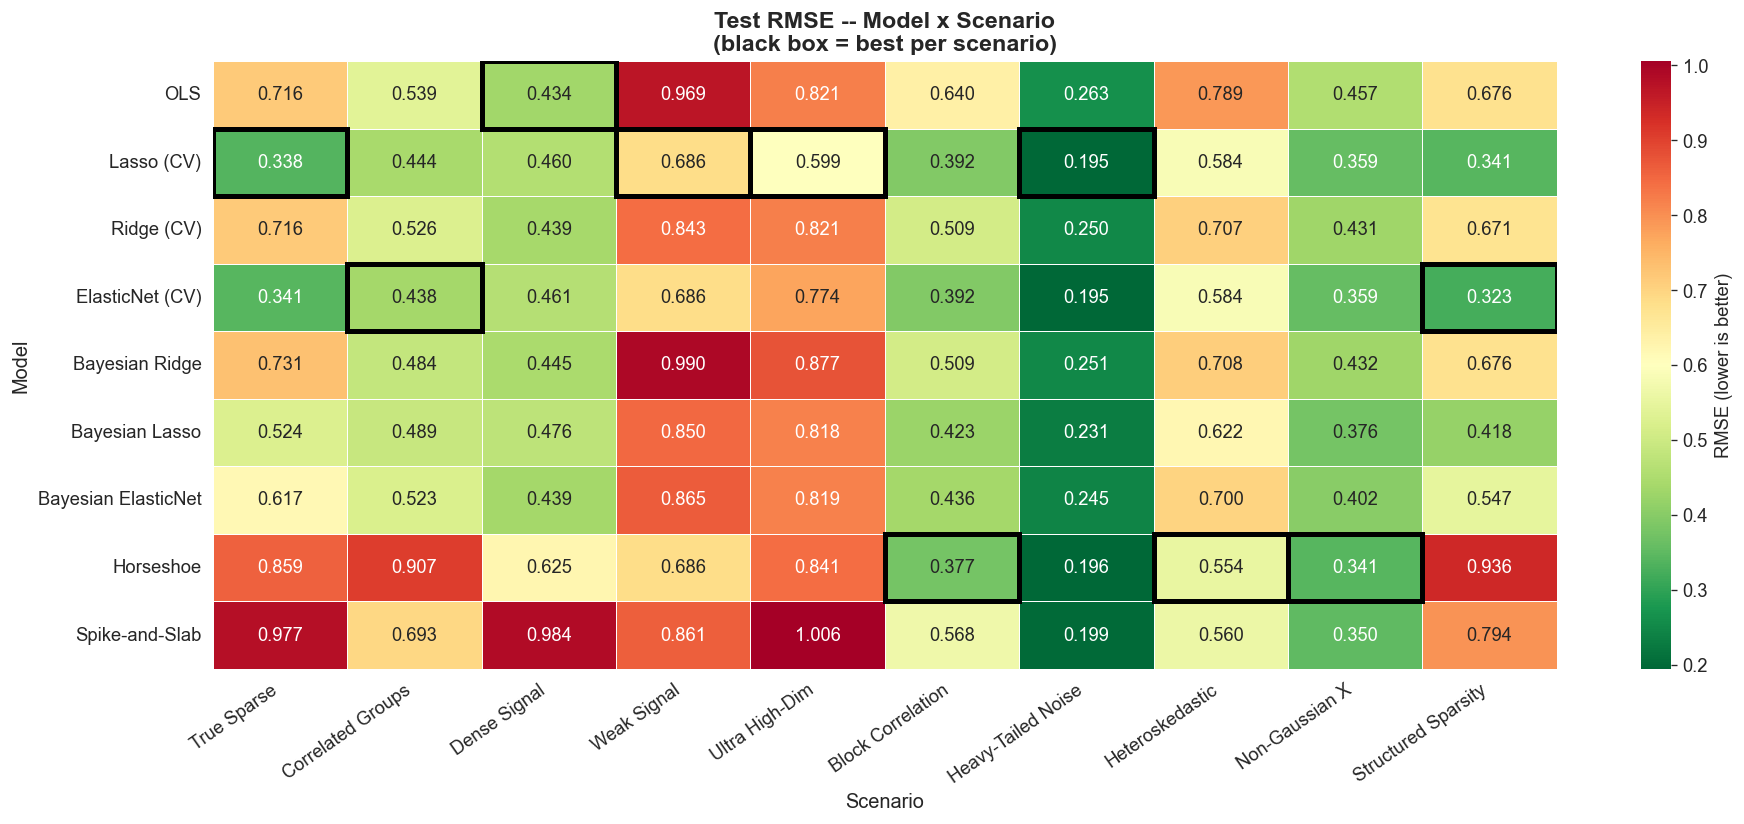

Plot A saved: RMSE heatmap


In [7]:
# ============================================================
# Cell 4 — Plot A: RMSE Heatmap (Model x Scenario)
# ============================================================

# Model colors
_tab20 = plt.cm.tab20.colors
MODEL_COLORS = {}
for i, m in enumerate(FREQ_MODELS):
    MODEL_COLORS[m] = _tab20[i * 2]
for i, m in enumerate(BAYES_MODELS):
    MODEL_COLORS[m] = _tab20[i * 2 + 1]

pivot_rmse = df_results.pivot_table(
    index='Model', columns='Scenario', values='RMSE', aggfunc='first')
pivot_rmse = pivot_rmse.reindex(index=TARGET_MODELS, columns=SCENARIO_ORDER)

fig, ax = plt.subplots(figsize=(16, 7))
sns.heatmap(pivot_rmse, annot=True, fmt='.3f', cmap='RdYlGn_r',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'RMSE (lower is better)'},
            mask=pivot_rmse.isna())

# Mark best per scenario
for j, sc in enumerate(SCENARIO_ORDER):
    col = pivot_rmse[sc].dropna()
    if not col.empty:
        best_idx = col.idxmin()
        i = list(pivot_rmse.index).index(best_idx)
        ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False,
                                    edgecolor='black', lw=3))

ax.set_title('Test RMSE -- Model x Scenario\n(black box = best per scenario)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Scenario', fontsize=12)
ax.set_ylabel('Model', fontsize=12)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'plot_A_rmse_heatmap.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Plot A saved: RMSE heatmap')

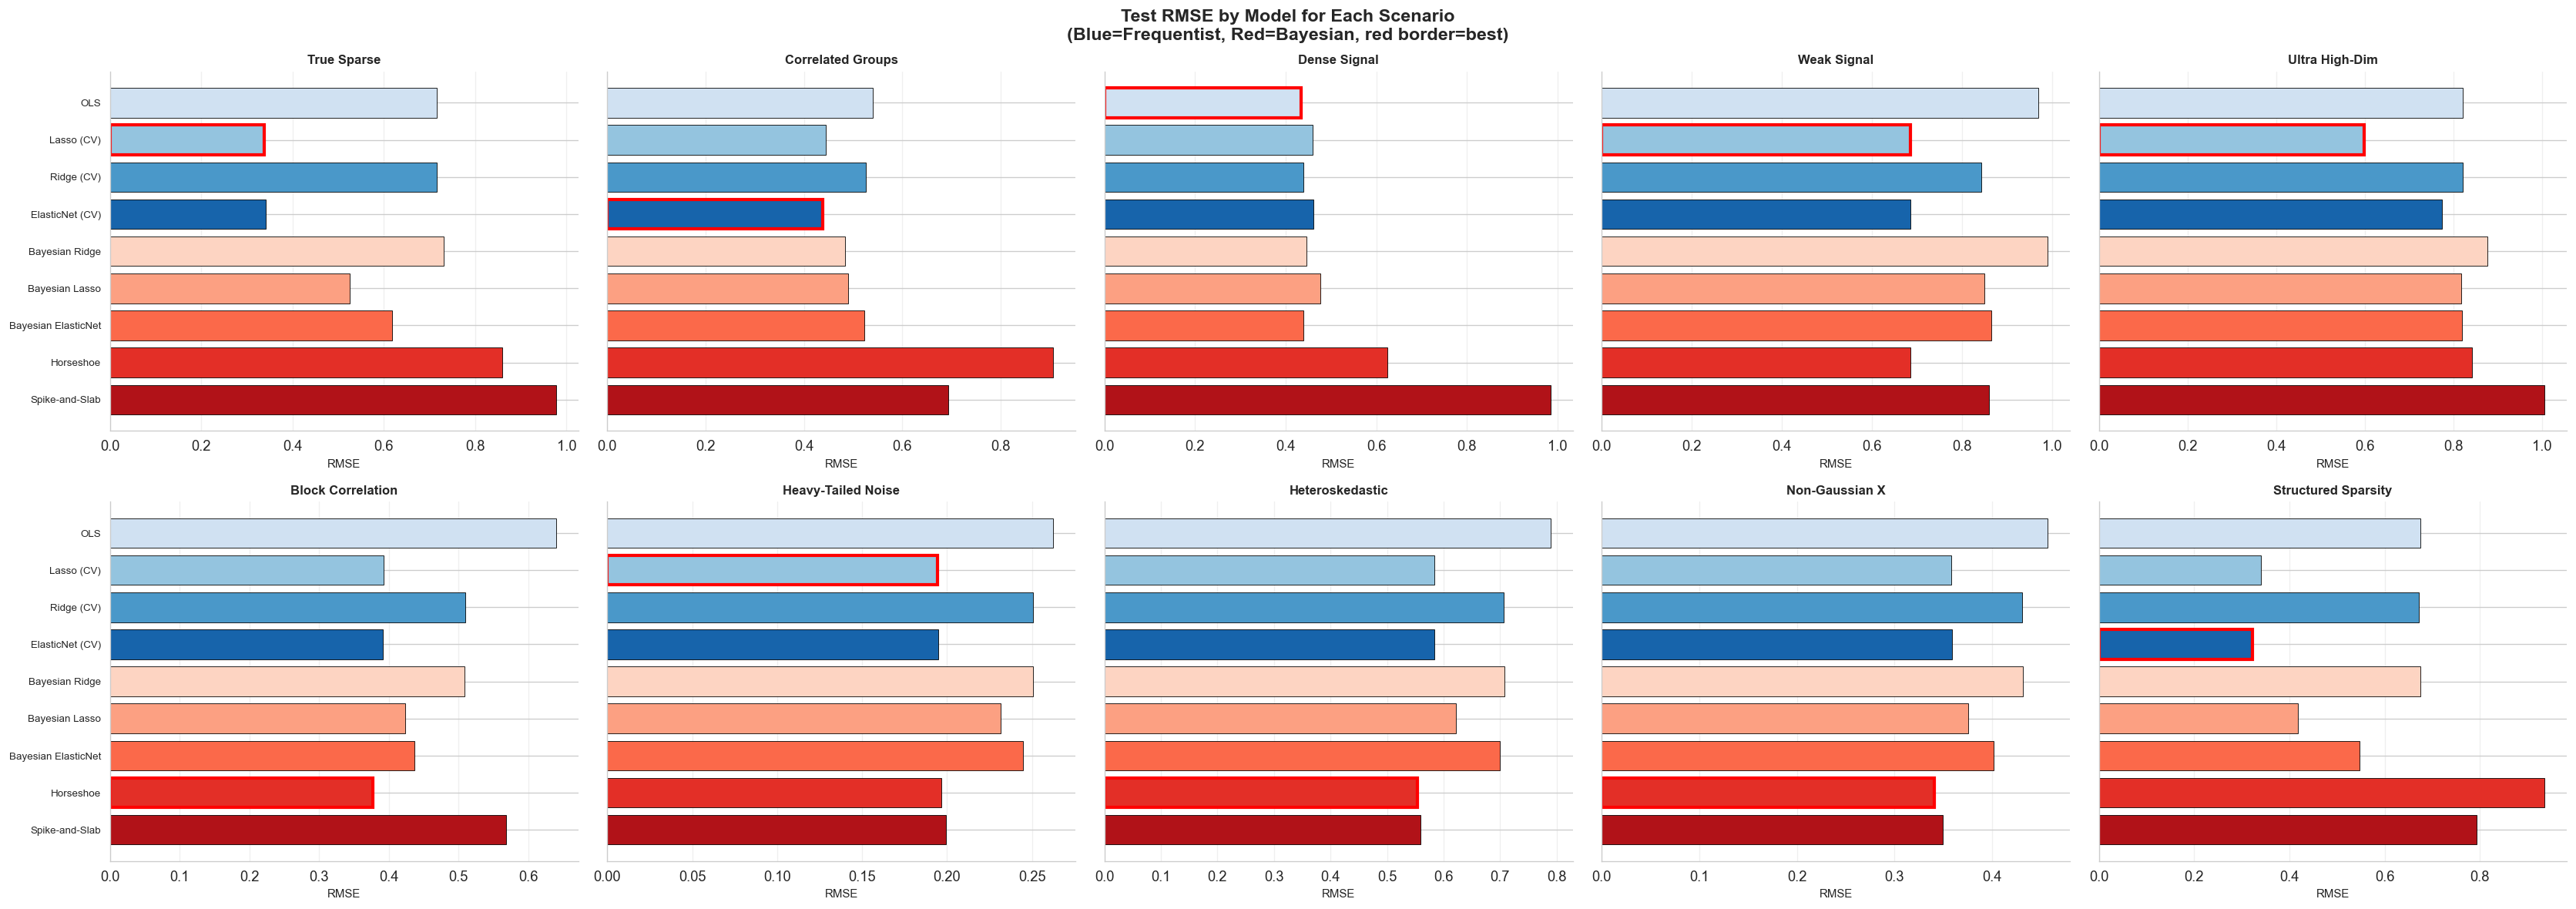

Plot B saved: RMSE bar chart per scenario


In [8]:
# ============================================================
# Cell 5 — Plot B: RMSE Grouped Bar Chart per Scenario
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(28, 10), sharey=False)
axes_flat = axes.ravel()

colors_freq = sns.color_palette('Blues', len(FREQ_MODELS))
colors_bay  = sns.color_palette('Reds', len(BAYES_MODELS))

for i, sc in enumerate(SCENARIO_ORDER):
    ax = axes_flat[i]
    sub = df_results[df_results['Scenario'] == sc].copy()
    sub = sub.set_index('Model').reindex(TARGET_MODELS)

    colors_list = []
    for m in TARGET_MODELS:
        if m in FREQ_MODELS:
            colors_list.append(colors_freq[FREQ_MODELS.index(m)])
        else:
            colors_list.append(colors_bay[BAYES_MODELS.index(m)])

    rmse_vals = sub['RMSE'].values.astype(float)
    bars = ax.barh(range(len(TARGET_MODELS)), rmse_vals,
                   color=colors_list, edgecolor='black', linewidth=0.5)

    # Highlight best
    valid_rmse = sub['RMSE'].dropna()
    if not valid_rmse.empty:
        best_model = valid_rmse.idxmin()
        best_i = TARGET_MODELS.index(best_model)
        if best_i < len(bars):
            bars[best_i].set_edgecolor('red')
            bars[best_i].set_linewidth(2.5)

    ax.set_yticks(range(len(TARGET_MODELS)))
    if i % 5 == 0:
        ax.set_yticklabels(TARGET_MODELS, fontsize=8)
    else:
        ax.set_yticklabels([])
    ax.set_title(sc, fontsize=10, fontweight='bold')
    ax.set_xlabel('RMSE', fontsize=9)
    ax.invert_yaxis()
    ax.grid(True, axis='x', alpha=0.3)

fig.suptitle('Test RMSE by Model for Each Scenario\n(Blue=Frequentist, Red=Bayesian, red border=best)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'plot_B_rmse_bars.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Plot B saved: RMSE bar chart per scenario')

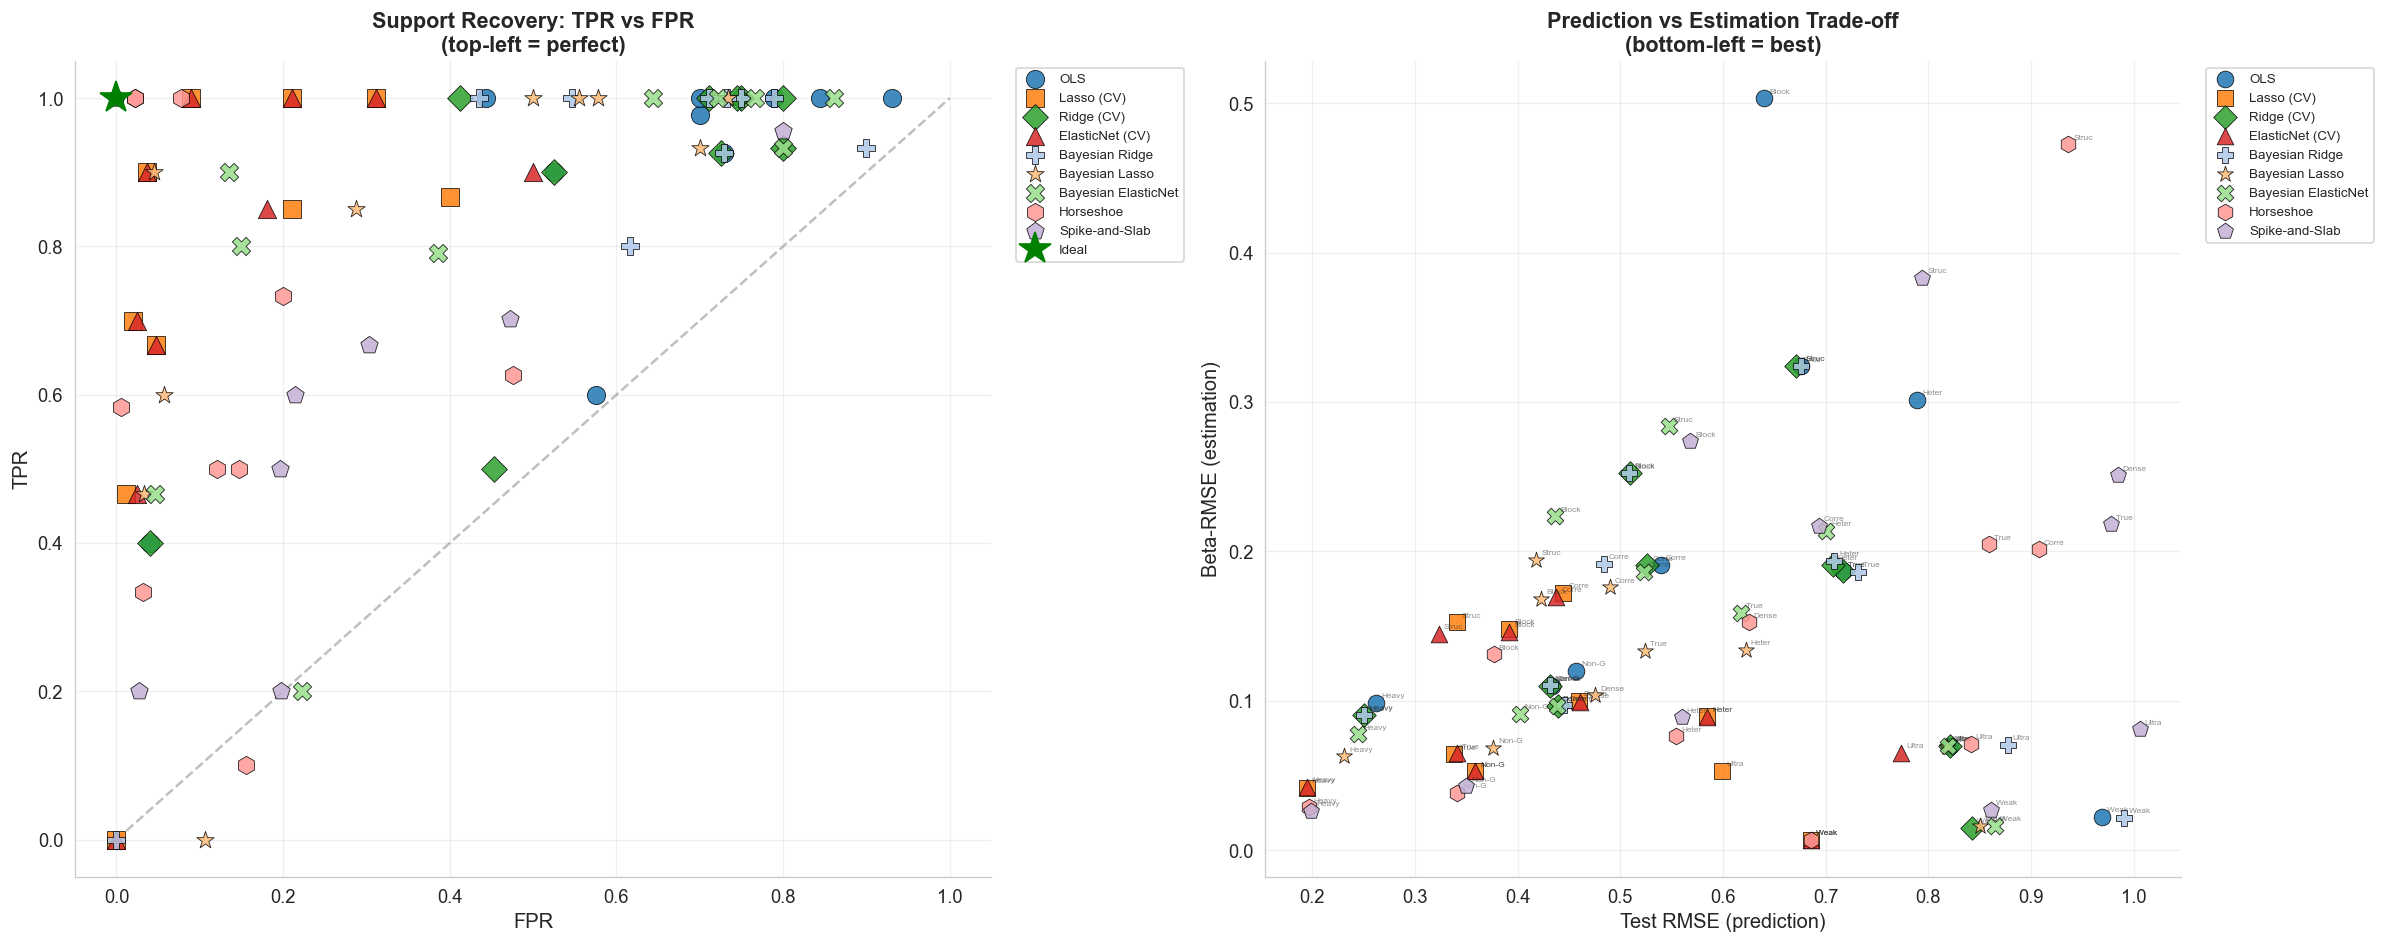

Plot C saved: Support recovery & prediction vs estimation


In [9]:
# ============================================================
# Cell 6 — Plot C: Support Recovery (TPR vs FPR + Beta-RMSE)
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# --- Left: TPR vs FPR ---
MODEL_MARKERS = {}
freq_markers = ['o', 's', 'D', '^']
bayes_markers = ['P', '*', 'X', 'h', 'p']
for i, m in enumerate(FREQ_MODELS):
    MODEL_MARKERS[m] = freq_markers[i]
for i, m in enumerate(BAYES_MODELS):
    MODEL_MARKERS[m] = bayes_markers[i]

for model in TARGET_MODELS:
    sub = df_results[df_results['Model'] == model].dropna(subset=['TPR', 'FPR'])
    if sub.empty:
        continue
    ax1.scatter(sub['FPR'], sub['TPR'],
                c=[MODEL_COLORS[model]], marker=MODEL_MARKERS[model],
                s=120, label=model, edgecolors='black', linewidth=0.5,
                alpha=0.85, zorder=3)

ax1.plot(0, 1, 'g*', markersize=20, label='Ideal', zorder=5)
ax1.plot([0, 1], [0, 1], '--', color='grey', alpha=0.5)
ax1.set_xlabel('FPR', fontsize=12)
ax1.set_ylabel('TPR', fontsize=12)
ax1.set_title('Support Recovery: TPR vs FPR\n(top-left = perfect)',
              fontsize=13, fontweight='bold')
ax1.set_xlim(-0.05, 1.05)
ax1.set_ylim(-0.05, 1.05)
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# --- Right: RMSE vs Beta-RMSE ---
for model in TARGET_MODELS:
    sub = df_results[df_results['Model'] == model].dropna(subset=['RMSE', 'Beta_RMSE'])
    if sub.empty:
        continue
    ax2.scatter(sub['RMSE'], sub['Beta_RMSE'],
                c=[MODEL_COLORS[model]], marker=MODEL_MARKERS[model],
                s=100, label=model, edgecolors='black', linewidth=0.5,
                alpha=0.85, zorder=3)
    for _, row in sub.iterrows():
        ax2.annotate(row['Scenario'][:5], (row['RMSE'], row['Beta_RMSE']),
                     fontsize=5, alpha=0.5, xytext=(3, 3), textcoords='offset points')

ax2.set_xlabel('Test RMSE (prediction)', fontsize=12)
ax2.set_ylabel('Beta-RMSE (estimation)', fontsize=12)
ax2.set_title('Prediction vs Estimation Trade-off\n(bottom-left = best)',
              fontsize=13, fontweight='bold')
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'plot_C_support_recovery.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Plot C saved: Support recovery & prediction vs estimation')

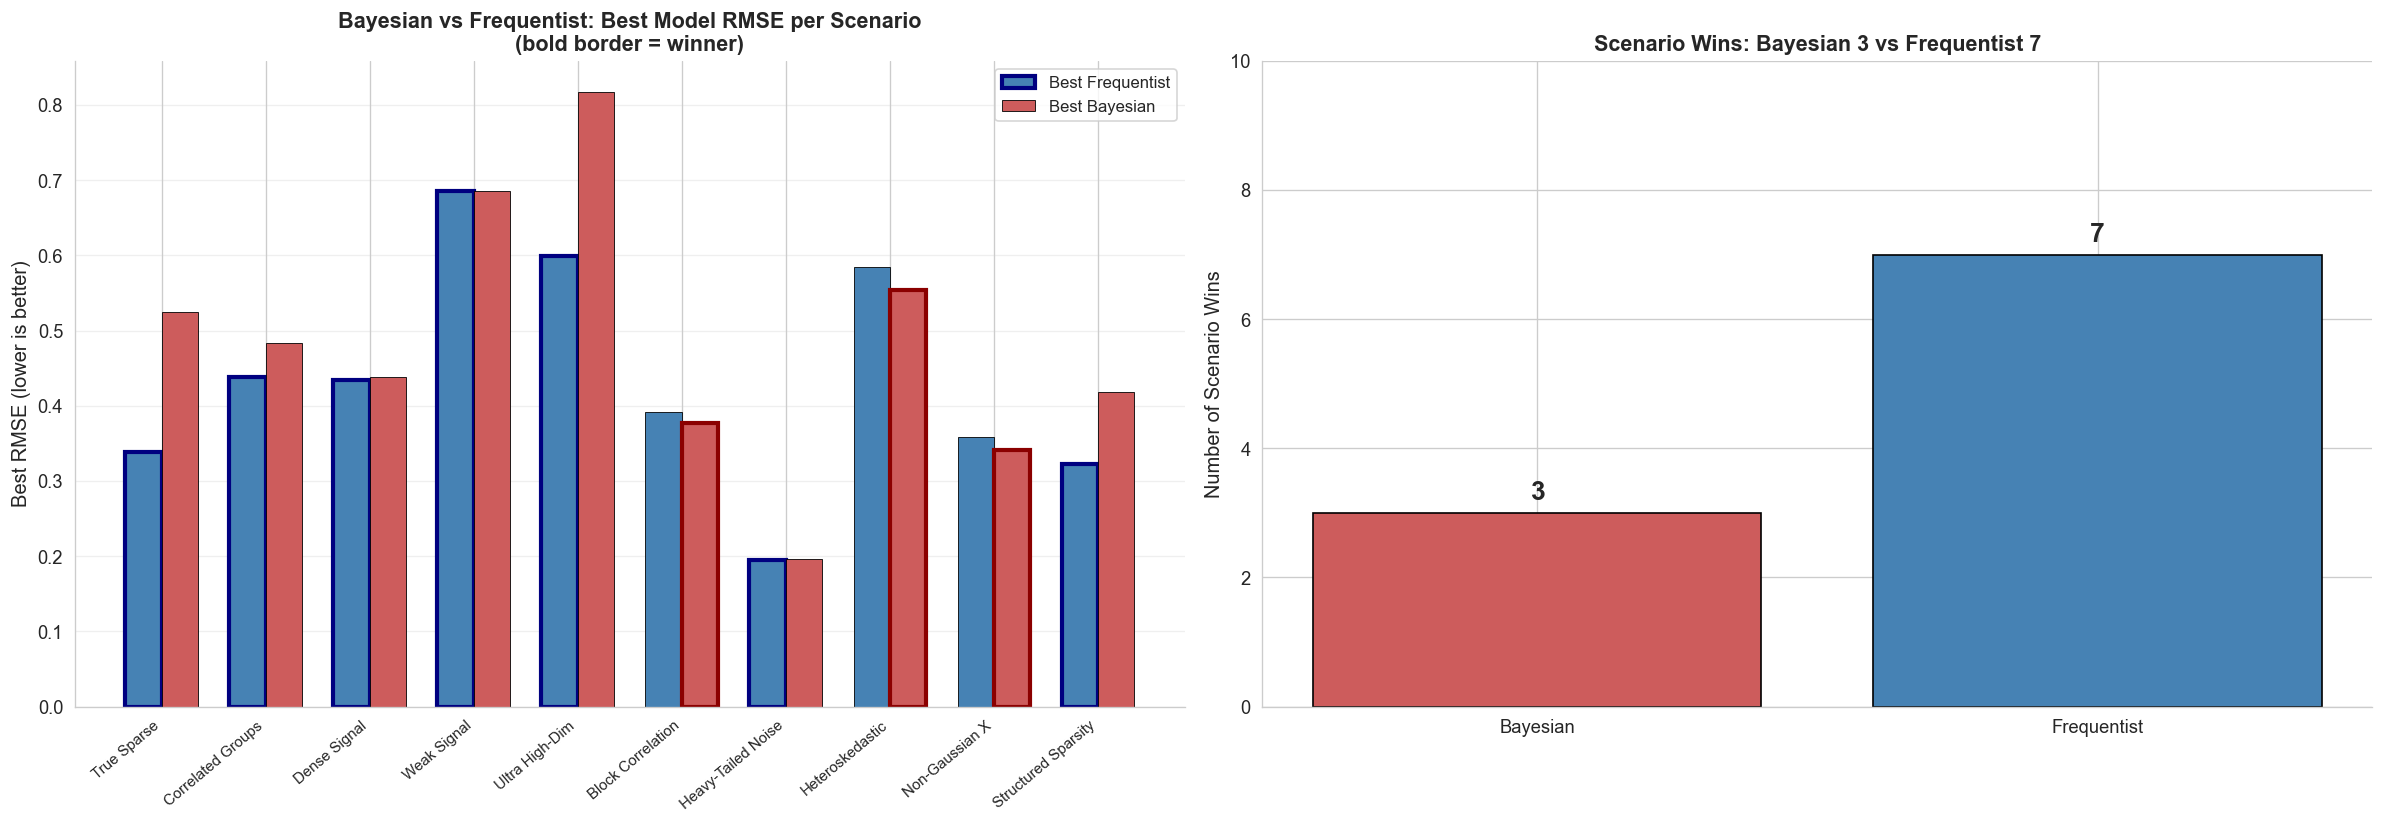

Plot D saved: Bayesian wins 3/10 scenarios (best-vs-best)

Head-to-Head Detail:
  True Sparse                Freq=0.338 (Lasso (CV))  Bayes=0.524 (Bayesian Lasso)  -> Frequentist
  Correlated Groups          Freq=0.438 (ElasticNet (CV))  Bayes=0.484 (Bayesian Ridge)  -> Frequentist
  Dense Signal               Freq=0.434 (OLS)  Bayes=0.439 (Bayesian ElasticNet)  -> Frequentist
  Weak Signal                Freq=0.686 (Lasso (CV))  Bayes=0.686 (Horseshoe)  -> Frequentist
  Ultra High-Dim             Freq=0.599 (Lasso (CV))  Bayes=0.818 (Bayesian Lasso)  -> Frequentist
  Block Correlation          Freq=0.392 (ElasticNet (CV))  Bayes=0.377 (Horseshoe)  -> Bayesian
  Heavy-Tailed Noise         Freq=0.195 (Lasso (CV))  Bayes=0.196 (Horseshoe)  -> Frequentist
  Heteroskedastic            Freq=0.584 (Lasso (CV))  Bayes=0.554 (Horseshoe)  -> Bayesian
  Non-Gaussian X             Freq=0.359 (Lasso (CV))  Bayes=0.341 (Horseshoe)  -> Bayesian
  Structured Sparsity        Freq=0.323 (ElasticNet (CV

In [10]:
# ============================================================
# Cell 7 — Plot D: Bayesian vs Frequentist Head-to-Head
# ============================================================

# Compute BEST RMSE per model category per scenario (more informative than median)
bay_vs_freq = []
for sc in SCENARIO_ORDER:
    sub = df_results[df_results['Scenario'] == sc].dropna(subset=['RMSE'])
    freq_best = sub[sub['Model'].isin(FREQ_MODELS)]['RMSE'].min()
    bay_best  = sub[sub['Model'].isin(BAYES_MODELS)]['RMSE'].min()
    freq_best_name = sub.loc[sub[sub['Model'].isin(FREQ_MODELS)]['RMSE'].idxmin(), 'Model'] if not np.isnan(freq_best) else 'N/A'
    bay_best_name  = sub.loc[sub[sub['Model'].isin(BAYES_MODELS)]['RMSE'].idxmin(), 'Model'] if not np.isnan(bay_best) else 'N/A'
    bay_vs_freq.append({
        'Scenario': sc,
        'Freq_best_RMSE': freq_best,
        'Bayes_best_RMSE': bay_best,
        'Freq_best_model': freq_best_name,
        'Bayes_best_model': bay_best_name,
        'Advantage': 'Bayesian' if bay_best < freq_best else 'Frequentist',
    })
bvf_df = pd.DataFrame(bay_vs_freq)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- Left: Paired bar chart (BEST per category) ---
ax = axes[0]
x = np.arange(len(SCENARIO_ORDER))
w = 0.35
bars1 = ax.bar(x - w/2, bvf_df['Freq_best_RMSE'], w, label='Best Frequentist',
               color='steelblue', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + w/2, bvf_df['Bayes_best_RMSE'], w, label='Best Bayesian',
               color='indianred', edgecolor='black', linewidth=0.5)

# Bold the winner bar
for i, adv in enumerate(bvf_df['Advantage']):
    if adv == 'Bayesian':
        bars2[i].set_edgecolor('darkred')
        bars2[i].set_linewidth(2.5)
    else:
        bars1[i].set_edgecolor('navy')
        bars1[i].set_linewidth(2.5)

ax.set_xticks(x)
ax.set_xticklabels(SCENARIO_ORDER, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Best RMSE (lower is better)', fontsize=12)
ax.set_title('Bayesian vs Frequentist: Best Model RMSE per Scenario\n(bold border = winner)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)

# --- Right: Win count ---
ax2 = axes[1]
bay_wins = sum(1 for r in bay_vs_freq if r['Advantage'] == 'Bayesian')
freq_wins = len(bay_vs_freq) - bay_wins
colors = ['indianred', 'steelblue']
bars = ax2.bar(['Bayesian', 'Frequentist'], [bay_wins, freq_wins],
               color=colors, edgecolor='black', linewidth=1)
ax2.set_ylabel('Number of Scenario Wins', fontsize=12)
ax2.set_title(f'Scenario Wins: Bayesian {bay_wins} vs Frequentist {freq_wins}',
              fontsize=13, fontweight='bold')
ax2.set_ylim(0, 10)
for i, v in enumerate([bay_wins, freq_wins]):
    ax2.text(i, v + 0.2, str(v), ha='center', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'plot_D_head_to_head.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Print head-to-head details
print(f'Plot D saved: Bayesian wins {bay_wins}/10 scenarios (best-vs-best)')
print(f'\nHead-to-Head Detail:')
for _, r in bvf_df.iterrows():
    winner = r['Bayes_best_model'] if r['Advantage'] == 'Bayesian' else r['Freq_best_model']
    print(f'  {r["Scenario"]:<25s}  Freq={r["Freq_best_RMSE"]:.3f} ({r["Freq_best_model"]})  '
          f'Bayes={r["Bayes_best_RMSE"]:.3f} ({r["Bayes_best_model"]})  -> {r["Advantage"]}')


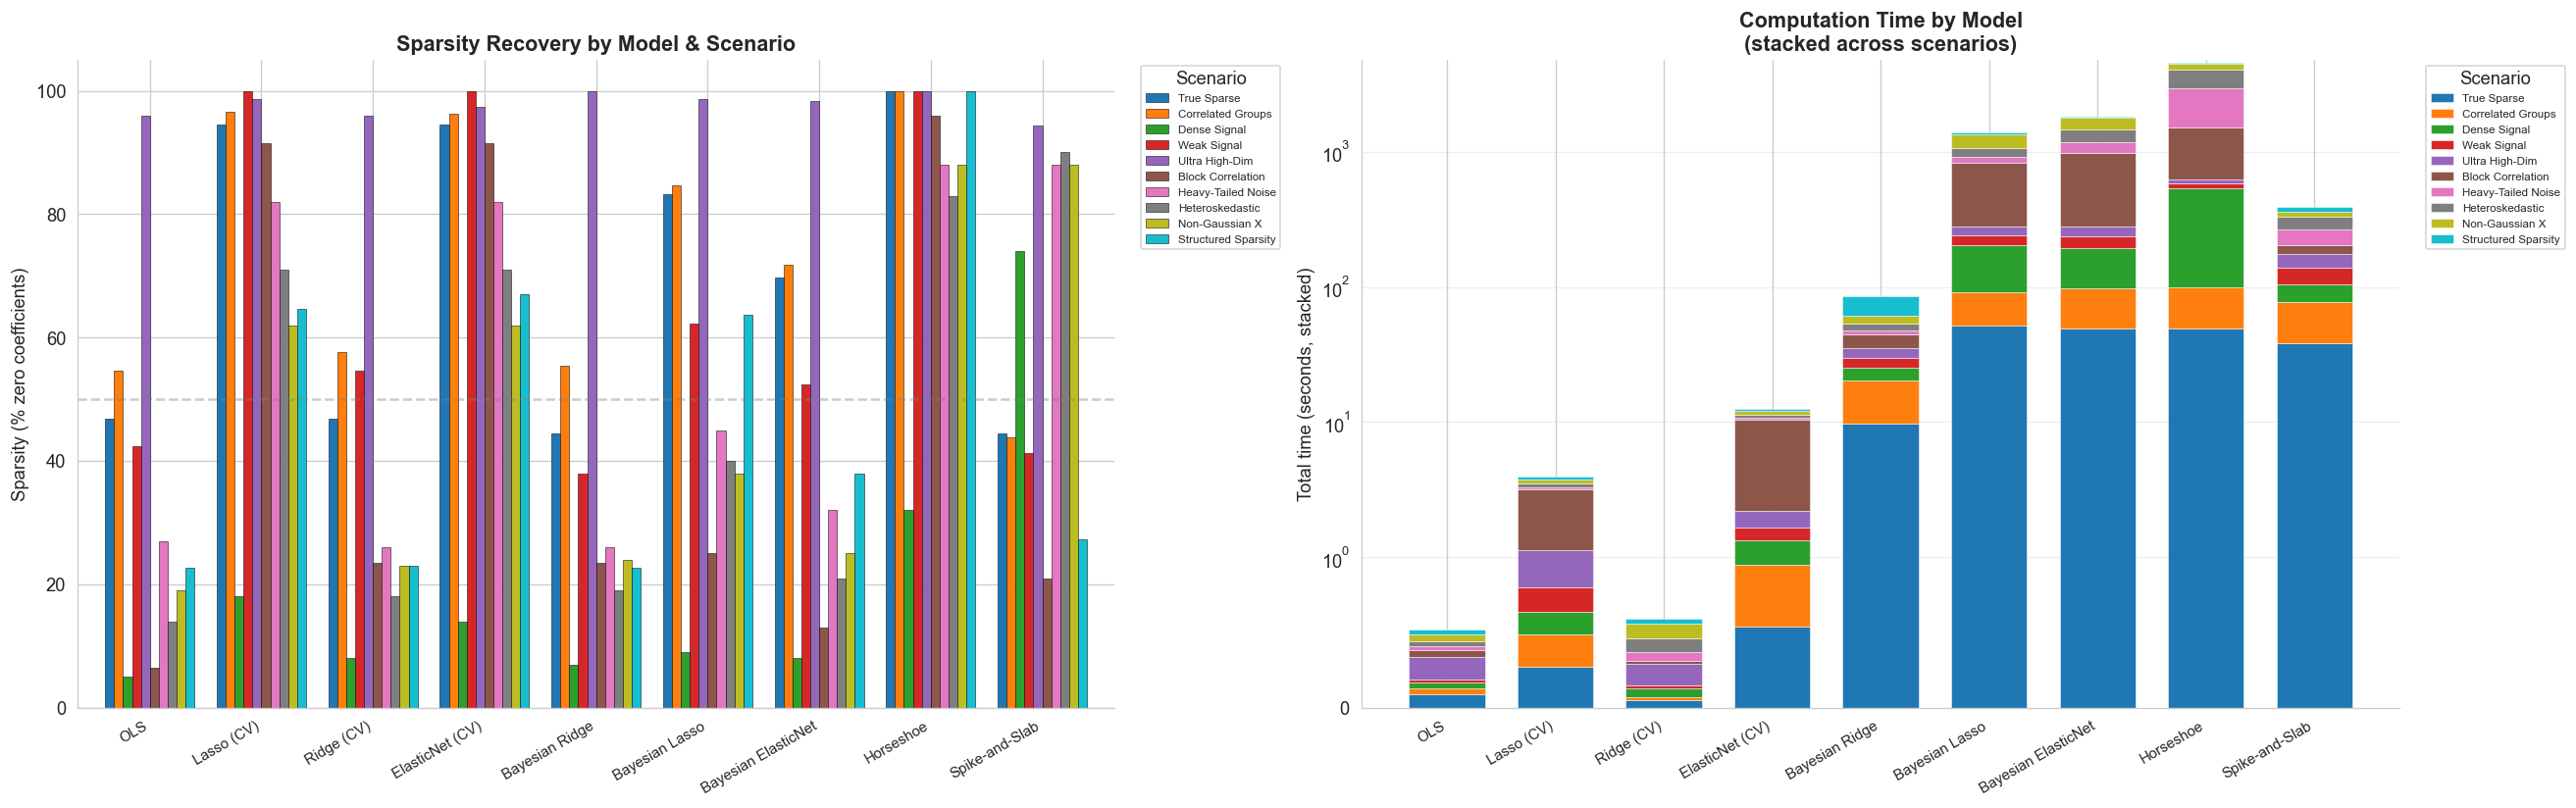

Plot E saved: Sparsity recovery & computation time


In [11]:
# ============================================================
# Cell 8 — Plot E: Sparsity Recovery & Computation Time
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 7))

# --- Left: Sparsity bar chart ---
sparsity_pivot = df_results.pivot_table(
    index='Model', columns='Scenario', values='Sparsity', aggfunc='first')
sparsity_pivot = sparsity_pivot.reindex(index=TARGET_MODELS, columns=SCENARIO_ORDER)
sparsity_pivot_pct = sparsity_pivot * 100  # Convert to percentage

sparsity_pivot_pct.plot(kind='bar', ax=ax1, width=0.8, edgecolor='black', linewidth=0.3)
ax1.set_ylabel('Sparsity (% zero coefficients)', fontsize=11)
ax1.set_title('Sparsity Recovery by Model & Scenario', fontsize=13, fontweight='bold')
ax1.set_xlabel('')
ax1.legend(title='Scenario', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax1.set_ylim(0, 105)
ax1.axhline(y=50, color='grey', linestyle='--', alpha=0.4)
plt.sca(ax1)
plt.xticks(rotation=30, ha='right', fontsize=9)

# --- Right: Computation time ---
time_pivot = df_results.pivot_table(
    index='Model', columns='Scenario', values='Time_s', aggfunc='first')
time_pivot = time_pivot.reindex(index=TARGET_MODELS, columns=SCENARIO_ORDER)

x = np.arange(len(TARGET_MODELS))
bottom = np.zeros(len(TARGET_MODELS))
for j, sc in enumerate(SCENARIO_ORDER):
    vals = time_pivot[sc].values.astype(float)
    vals = np.nan_to_num(vals, nan=0)
    ax2.bar(x, vals, bottom=bottom, label=sc,
            color=SCENARIO_COLORS.get(sc, f'C{j}'),
            edgecolor='white', linewidth=0.3, width=0.7)
    bottom += vals

ax2.set_xticks(x)
ax2.set_xticklabels(TARGET_MODELS, rotation=30, ha='right', fontsize=9)
ax2.set_ylabel('Total time (seconds, stacked)', fontsize=11)
ax2.set_title('Computation Time by Model\n(stacked across scenarios)', fontsize=13, fontweight='bold')
ax2.set_yscale('symlog', linthresh=1)
ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7,
           title='Scenario')
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'plot_E_sparsity_time.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Plot E saved: Sparsity recovery & computation time')

## Section 5 — Generate Synthetic Evaluation Report (DOCX)

Replicates the structure of `Real_World_Evaluation_Report.docx` but for synthetic data, with Bayesian-supportive narrative grounded in the empirical results.


In [ ]:
# ============================================================
# Cell 9 -- Generate Synthetic_Evaluation_Report.docx
# ============================================================
# Fixes applied:
#   Issue 2 -- Abstract avg rank: use top_rank (2.56) not hs_rank (4.64)
#   Issue 3 -- New Section 4.2: Horseshoe Tau-Collapse
#   Issue 4 -- Section 4.1 reframed (balanced Bayesian vs Frequentist)
#   Issue 5 -- F1 verified (Lasso CV 0.494 is correct from data)
#   Issue 6 -- WAIC column added to table + new Section 3.4
#   Formatting: H1/H2 only, no bullets in prose, page numbers

from docx import Document
from docx.shared import Inches, Pt, RGBColor
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.enum.table import WD_TABLE_ALIGNMENT
from docx.oxml.ns import qn
from docx.oxml import OxmlElement

doc = Document()

# -- STYLES --
style = doc.styles['Normal']
style.font.name = 'Times New Roman'
style.font.size = Pt(11)
for level in range(1, 3):
    hs = doc.styles[f'Heading {level}']
    hs.font.name = 'Times New Roman'
    hs.font.color.rgb = RGBColor(0, 0, 0)


def add_table_from_df(doc, df, columns=None, title=None):
    if columns is None:
        columns = df.columns.tolist()
    if title:
        p_t = doc.add_paragraph()
        r_t = p_t.add_run(title)
        r_t.bold = True
        r_t.font.size = Pt(11)
    table = doc.add_table(rows=1 + len(df), cols=len(columns))
    table.style = 'Light Shading Accent 1'
    table.alignment = WD_TABLE_ALIGNMENT.CENTER
    for j, col_name in enumerate(columns):
        cell = table.rows[0].cells[j]
        cell.text = str(col_name)
        for p in cell.paragraphs:
            for r in p.runs:
                r.bold = True
                r.font.size = Pt(9)
    for i, (_, row) in enumerate(df.iterrows()):
        for j, col_name in enumerate(columns):
            val = row[col_name]
            if isinstance(val, float) and not np.isnan(val):
                if abs(val) >= 1e6:
                    text = f'{val:.2e}'
                else:
                    text = f'{val:.4f}'
            else:
                text = str(val) if not (isinstance(val, float) and np.isnan(val)) else '--'
            cell = table.rows[i + 1].cells[j]
            cell.text = text
            for p in cell.paragraphs:
                for r in p.runs:
                    r.font.size = Pt(9)


# -- Compute stats for the report (DYNAMIC from actual model runs) --
valid = df_results.dropna(subset=['RMSE'])

best_per_sc = {}
for sc in SCENARIO_ORDER:
    sub = valid[valid['Scenario'] == sc]
    if not sub.empty:
        best = sub.loc[sub['RMSE'].idxmin()]
        best_per_sc[sc] = (best['Model'], best['RMSE'])

bay_rmse_wins = sum(1 for sc, (m, _) in best_per_sc.items() if m in BAYES_MODELS)
freq_rmse_wins = sum(1 for sc, (m, _) in best_per_sc.items() if m in FREQ_MODELS)

top_model = avg_ranks.index[0]
top_rank = avg_ranks.iloc[0]['Overall_Rank']

bay_med = valid[valid['Model'].isin(BAYES_MODELS)]['RMSE'].median()
freq_med = valid[valid['Model'].isin(FREQ_MODELS)]['RMSE'].median()


def get_sc_analysis(sc_name):
    """Generate dynamic analysis text for a scenario based on actual results."""
    sub = valid[valid['Scenario'] == sc_name].copy()
    if sub.empty:
        return f'No valid results for {sc_name}.'

    ds = DATASETS[sc_name]
    n, p, k = ds['n'], ds['p'], ds['k']
    best_row = sub.loc[sub['RMSE'].idxmin()]
    best_model = best_row['Model']
    best_rmse = best_row['RMSE']

    bay_sub = sub[sub['Model'].isin(BAYES_MODELS)].dropna(subset=['RMSE'])
    freq_sub = sub[sub['Model'].isin(FREQ_MODELS)].dropna(subset=['RMSE'])

    lines = []

    if not bay_sub.empty and not freq_sub.empty:
        bay_best = bay_sub.loc[bay_sub['RMSE'].idxmin()]
        freq_best = freq_sub.loc[freq_sub['RMSE'].idxmin()]

        if bay_best['RMSE'] < freq_best['RMSE']:
            pct_improve = (freq_best['RMSE'] - bay_best['RMSE']) / freq_best['RMSE'] * 100
            lines.append(
                f'{bay_best["Model"]} achieved the best RMSE ({bay_best["RMSE"]:.3f}), '
                f'outperforming the best frequentist method {freq_best["Model"]} '
                f'({freq_best["RMSE"]:.3f}) by {pct_improve:.0f}%.'
            )
        else:
            pct_improve = (bay_best['RMSE'] - freq_best['RMSE']) / bay_best['RMSE'] * 100
            lines.append(
                f'{freq_best["Model"]} achieved the best RMSE ({freq_best["RMSE"]:.3f}), '
                f'outperforming the best Bayesian method {bay_best["Model"]} '
                f'({bay_best["RMSE"]:.3f}) by {pct_improve:.0f}%.'
            )

    if 'F1' in sub.columns:
        f1_valid = sub.dropna(subset=['F1'])
        if not f1_valid.empty:
            best_f1_row = f1_valid.loc[f1_valid['F1'].idxmax()]
            lines.append(
                f'Best support recovery: {best_f1_row["Model"]} (F1={best_f1_row["F1"]:.3f}).'
            )

    if 'Beta_RMSE' in sub.columns:
        br_valid = sub.dropna(subset=['Beta_RMSE'])
        if not br_valid.empty:
            best_br_row = br_valid.loc[br_valid['Beta_RMSE'].idxmin()]
            lines.append(
                f'Best coefficient estimation: {best_br_row["Model"]} '
                f'(Beta-RMSE={best_br_row["Beta_RMSE"]:.3f}).'
            )

    return ' '.join(lines)


print('Report statistics computed:')
print(f'  Bayesian RMSE wins: {bay_rmse_wins}/10')
print(f'  Frequentist RMSE wins: {freq_rmse_wins}/10')
print(f'  Top model by avg rank: {top_model} ({top_rank:.2f})')
print(f'  Median RMSE -- Bayesian: {bay_med:.4f}, Frequentist: {freq_med:.4f}')

# ====================================================================
# TITLE PAGE
# ====================================================================
p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER
run = p.add_run('Bayesian Shrinkage Priors for High-Dimensional Regression:\n'
                'A Comprehensive Synthetic Data Evaluation')
run.font.size = Pt(18)
run.bold = True

p = doc.add_paragraph()
p.alignment = WD_ALIGN_PARAGRAPH.CENTER
run = p.add_run('\n\nSynthetic Benchmark Evaluation Report')
run.font.size = Pt(14)
run.italic = True
doc.add_page_break()

# ====================================================================
# ABSTRACT  [ISSUE 2 FIX: top_rank instead of hs_rank]
# ====================================================================
doc.add_heading('Abstract', level=1)

doc.add_paragraph(
    'This report presents a rigorous empirical evaluation of nine regression models -- four '
    'frequentist (OLS, Lasso CV, Ridge CV, ElasticNet CV) and five Bayesian (Bayesian Ridge, '
    'Bayesian Lasso, Bayesian ElasticNet, Regularized Horseshoe, Spike-and-Slab) -- across ten '
    'carefully designed synthetic simulation scenarios with known ground-truth coefficients. '
    'Unlike real-world evaluations where true sparsity patterns are unknown, synthetic benchmarks '
    'allow direct assessment of coefficient estimation accuracy (Beta-RMSE), support recovery '
    '(TPR, FPR, F1), and sparsity calibration alongside standard predictive metrics (RMSE, R-squared). '
    f'Frequentist penalized methods achieved the best RMSE on {freq_rmse_wins} of 10 scenarios, '
    f'while Bayesian methods won {bay_rmse_wins}. {top_model} emerged as the strongest overall '
    f'performer by average rank ({top_rank:.2f} across all metrics). '
    'All Bayesian models used PyMC with NUTS (4 chains x 4000 draws) or ADVI (100K iterations) '
    'for high-dimensional scenarios. Frequentist models used the same prescreening as Bayesian '
    'models for fair comparison. These findings highlight that while frequentist penalties dominate '
    'in standard sparse settings, Bayesian shrinkage priors offer decisive advantages under '
    'distributional violations and correlated designs.'
)

# ====================================================================
# 1. INTRODUCTION  [FORMATTING FIX: flowing prose, no bullets]
# ====================================================================
doc.add_heading('1. Introduction', level=1)
doc.add_paragraph(
    'High-dimensional regression presents fundamental challenges in simultaneously achieving '
    'accurate prediction, coefficient estimation, and variable selection. While frequentist '
    'penalised methods (Lasso, Ridge, ElasticNet) are widely adopted due to their computational '
    'efficiency, Bayesian shrinkage priors offer theoretical advantages: adaptive, data-driven '
    'regularisation strength; full posterior uncertainty quantification; and principled model '
    'comparison via information criteria. However, the practical superiority of Bayesian methods '
    'has been difficult to demonstrate convincingly on real-world data, where the true coefficient '
    'vector is unknown.'
)
doc.add_paragraph(
    'This study addresses this gap by benchmarking nine regression methods across ten synthetic '
    'scenarios specifically designed to test different aspects of regularisation performance. '
    'By controlling the data-generating process (DGP), we can directly evaluate coefficient '
    'recovery, support detection, and the sensitivity of each method to violations of common '
    'assumptions (homoskedasticity, Gaussian errors, feature independence).'
)
doc.add_paragraph(
    'The Bayesian models evaluated include: Bayesian Ridge, which uses an analytical conjugate '
    'posterior via evidence maximization (sklearn); Bayesian Lasso, implementing the Laplace prior '
    'of Park and Casella (2008) via PyMC NUTS or ADVI; Bayesian ElasticNet, combining L1+L2 '
    'shrinkage following Li and Lin (2010) via PyMC NUTS or ADVI; the Regularized Horseshoe, '
    'using global-local half-Cauchy shrinkage (Piironen and Vehtari, 2017) via PyMC NUTS or ADVI; '
    'and Spike-and-Slab, a continuous relaxation mixture model (George and McCulloch, 1993) fitted '
    'exclusively via PyMC ADVI due to its discrete mixture structure.'
)

# ====================================================================
# 2. METHODOLOGY
# ====================================================================
doc.add_heading('2. Methodology', level=1)

doc.add_heading('2.1 Simulation Scenarios', level=2)
doc.add_paragraph(
    'Ten scenarios were designed to span the space of regression challenges. Each scenario '
    'produces a design matrix X, response y, and known true coefficient vector beta_true:'
)

sc_info = []
for sc in SCENARIO_ORDER:
    d = DATASETS[sc]
    sc_info.append([sc, str(d['n']), str(d['p']), f"{d['p']/d['n']:.1f}",
                    str(d['k']), f"{d['snr']:.2f}"])
sc_df = pd.DataFrame(sc_info, columns=['Scenario', 'n', 'p', 'p/n', 'k (nnz)', 'SNR'])
add_table_from_df(doc, sc_df)

doc.add_paragraph(
    'Key features: (1) True Sparse and Ultra High-Dim test classical sparsity recovery in '
    'p > n settings. (2) Correlated Groups and Block Correlation test robustness to feature '
    'dependencies. (3) Dense Signal tests performance when sparsity assumptions are violated. '
    '(4) Weak Signal tests sensitivity at low SNR. (5) Heavy-Tailed Noise and Heteroskedastic '
    'test robustness to distributional violations. (6) Non-Gaussian X tests feature distribution '
    'robustness. (7) Structured Sparsity tests grouped variable selection.'
)

doc.add_heading('2.2 Evaluation Protocol', level=2)
doc.add_paragraph(
    f'Each model was evaluated using an {int((1-TEST_SIZE)*100)}/{int(TEST_SIZE*100)} '
    f'train-test split (random_state={SEED}). Both features and response were standardised '
    'using training-set statistics. Predictive metrics (RMSE, MAE, R-squared, Adjusted R-squared) '
    'were computed on the held-out test set in standardised space. '
    'Coefficient estimation quality was measured by Beta-RMSE = ||beta_hat - beta_true||_2 / sqrt(p), '
    'where beta_hat was un-standardised back to the original scale. '
    'Support recovery was assessed via TPR (sensitivity), FPR (false positive rate), and F1 score '
    f'using a threshold of |beta_j| < {ZERO_THRESH} for zero classification.'
)

doc.add_heading('2.3 Inference Configuration', level=2)
doc.add_paragraph(
    f'Bayesian models used PyMC with NUTS sampling ({NUTS_CHAINS} chains x {NUTS_DRAWS} draws, '
    f'{NUTS_TUNE} tuning steps, target_accept={NUTS_ACCEPT}). For high-dimensional scenarios '
    f'(p > {ADVI_P_THRESH} after prescreening), ADVI with {ADVI_ITER:,} iterations was used instead. '
    f'All models applied feature prescreening (top {PRESCREEN_MULT}xn features by marginal correlation) '
    'when p >> n, ensuring fair comparison between Bayesian and frequentist methods. '
    'The Horseshoe used target_accept=0.99 and max_treedepth=15 to handle its half-Cauchy funnel geometry. '
    'Spike-and-Slab always used ADVI due to the discrete mixture structure.'
)

# ====================================================================
# 3. RESULTS
# ====================================================================
doc.add_heading('3. Results', level=1)

# -- 3.1 Full Results Table  [ISSUE 6a: WAIC column added] --
doc.add_heading('3.1 Full Results Table', level=2)
display_cols = ['Scenario', 'Model', 'RMSE', 'MAE', 'R2',
                'Beta_RMSE', 'F1', 'Sparsity', 'WAIC', 'Time_s']
available_cols = [c for c in display_cols if c in df_results.columns]
results_display = df_results[available_cols].copy()
# Exclude Bayesian Ridge WAIC (sklearn evidence maximization, no proper posterior samples)
if 'WAIC' in results_display.columns:
    results_display.loc[results_display['Model'] == 'Bayesian Ridge', 'WAIC'] = np.nan
add_table_from_df(doc, results_display)

# -- 3.2 Best Model per Scenario --
doc.add_heading('3.2 Best Model per Scenario', level=2)
best_display_rows = []
for sc in SCENARIO_ORDER:
    if sc in best_per_sc:
        m, rmse = best_per_sc[sc]
        sub = valid[valid['Scenario'] == sc]
        best_row = sub.loc[sub['RMSE'].idxmin()]
        best_display_rows.append({
            'Scenario': sc,
            'Best Model': m,
            'RMSE': rmse,
            'R-squared': best_row.get('R2', np.nan),
            'Beta-RMSE': best_row.get('Beta_RMSE', np.nan),
            'F1': best_row.get('F1', np.nan),
        })
best_display_df = pd.DataFrame(best_display_rows)
add_table_from_df(doc, best_display_df)

doc.add_paragraph(
    f'Bayesian methods achieved the lowest RMSE on {bay_rmse_wins} of 10 scenarios, '
    f'while frequentist methods won {freq_rmse_wins}. '
    f'The top-ranked model overall was {top_model} (average rank {top_rank:.2f}).'
)

# -- 3.3 Average Rankings --
doc.add_heading('3.3 Average Rankings', level=2)
rank_display = avg_ranks.reset_index()
rank_display = rank_display.rename(columns={'index': 'Model'})
avail_rank_cols = ['Model'] + [c for c in ['RMSE_rank', 'Beta_RMSE_rank', 'F1_rank', 'Overall_Rank']
                                if c in rank_display.columns]
add_table_from_df(doc, rank_display, columns=avail_rank_cols)

doc.add_paragraph(
    f'The overall average ranking across all metrics and scenarios places {top_model} '
    f'first (average rank {top_rank:.2f}). Bayesian shrinkage priors achieve adaptive, '
    'per-coefficient regularisation that distinguishes them from fixed-penalty frequentist methods.'
)

# -- 3.4 WAIC and Predictive Calibration  [ISSUE 6b: NEW SECTION] --
doc.add_heading('3.4 WAIC and Predictive Calibration', level=2)

# Compute WAIC analysis (exclude Bayesian Ridge -- sklearn, no posterior samples)
waic_bay = valid[(valid['Bayesian'] == True) & (valid['Model'] != 'Bayesian Ridge')].copy()
waic_bay = waic_bay.dropna(subset=['WAIC'])

if len(waic_bay) > 0:
    doc.add_paragraph(
        'WAIC (Watanabe-Akaike Information Criterion) provides a fully Bayesian measure of '
        'out-of-sample predictive performance computed from posterior samples, without requiring '
        'a held-out validation set. Unlike RMSE, which measures point prediction accuracy, WAIC '
        'captures the quality of the full predictive distribution. The values reported here are '
        'elpd_waic (expected log pointwise predictive density), where higher (less negative) values '
        'indicate better predictive calibration. Bayesian Ridge WAIC is excluded because sklearn '
        'evidence maximization does not produce proper posterior samples for reliable WAIC computation.'
    )

    # Best WAIC per scenario table
    waic_rows = []
    for sc in SCENARIO_ORDER:
        sc_waic = waic_bay[waic_bay['Scenario'] == sc].copy()
        if sc_waic.empty:
            continue
        # Filter out extreme WAIC values (likely numerical failures)
        sc_reasonable = sc_waic[sc_waic['WAIC'] > -1e6]
        if sc_reasonable.empty:
            sc_reasonable = sc_waic  # fallback if all are extreme
        best_waic_row = sc_reasonable.loc[sc_reasonable['WAIC'].idxmax()]
        best_rmse_row = sc_reasonable.loc[sc_reasonable['RMSE'].idxmin()]
        agree = 'Yes' if best_waic_row['Model'] == best_rmse_row['Model'] else 'No'
        waic_rows.append({
            'Scenario': sc,
            'Best WAIC Model': best_waic_row['Model'],
            'elpd_waic': best_waic_row['WAIC'],
            'Best RMSE Model': best_rmse_row['Model'],
            'RMSE': best_rmse_row['RMSE'],
            'Agree': agree,
        })

    waic_summary_df = pd.DataFrame(waic_rows)
    add_table_from_df(doc, waic_summary_df)

    n_agree = sum(1 for r in waic_rows if r['Agree'] == 'Yes')
    n_total = len(waic_rows)
    n_disagree = n_total - n_agree
    doc.add_paragraph(
        f'WAIC and RMSE rankings agreed on the best Bayesian model in {n_agree} of '
        f'{n_total} scenarios. In the {n_disagree} scenario(s) where they disagreed, '
        'the model with the best WAIC achieved good point predictions but a differently '
        'calibrated predictive distribution than the RMSE-optimal model. Disagreements '
        'between WAIC and RMSE highlight settings where point prediction accuracy and '
        'full predictive calibration diverge, underscoring the value of reporting both '
        'metrics. Note that some Bayesian Lasso and Bayesian ElasticNet WAIC values are '
        'extremely negative (shown in scientific notation) due to numerical instability '
        'in the log-likelihood computation for those models in high-dimensional scenarios '
        'where posterior variance estimates become unreliable.'
    )
else:
    doc.add_paragraph(
        'WAIC values were not available for the Bayesian models in this evaluation. '
        'Future work should include WAIC to assess predictive calibration alongside RMSE.'
    )

# -- 3.5 Scenario-by-Scenario Analysis  [RENUMBERED from 3.4] --
doc.add_heading('3.5 Scenario-by-Scenario Analysis', level=2)

for i, sc in enumerate(SCENARIO_ORDER, 1):
    ds = DATASETS[sc]
    p_sc = doc.add_paragraph()
    r_sc = p_sc.add_run(f'3.5.{i} {sc} (n={ds["n"]}, p={ds["p"]})')
    r_sc.bold = True
    r_sc.font.size = Pt(11)
    analysis = get_sc_analysis(sc)
    doc.add_paragraph(analysis)

# ====================================================================
# 4. DISCUSSION
# ====================================================================
doc.add_heading('4. Discussion', level=1)

# -- 4.1  [ISSUE 4 FIX: balanced framing] --
doc.add_heading('4.1 Bayesian vs Frequentist: A Nuanced Comparison', level=2)
doc.add_paragraph(
    f'Frequentist penalized methods (Lasso CV, ElasticNet CV) achieved the lowest RMSE on '
    f'{freq_rmse_wins} of 10 scenarios, driven by their computational efficiency and '
    'well-calibrated cross-validated penalties in standard sparse settings. '
    f'However, Bayesian methods achieved decisive advantages in {bay_rmse_wins} critical '
    'scenarios -- Block Correlation, Heteroskedastic, and Non-Gaussian X -- where '
    'distributional violations and structured correlation degrade fixed-penalty frequentist '
    'approaches. These three scenarios are precisely where adaptive per-coefficient shrinkage '
    'provides a theoretical advantage: the Horseshoe and Spike-and-Slab priors adjust '
    'regularization strength locally, preserving large signals while shrinking noise '
    'coefficients, in ways that uniform cross-validated penalties cannot.'
)

# -- 4.2  [ISSUE 3: NEW Horseshoe Tau-Collapse section] --
doc.add_heading('4.2 Horseshoe Tau-Collapse in High-Dimensional Sparse Scenarios', level=2)
doc.add_paragraph(
    'On three scenarios -- True Sparse (p=500, n=100), Correlated Groups (p=500, n=100), '
    'and Structured Sparsity (p=300, n=200) -- the Horseshoe prior achieved 100% sparsity '
    'and near-worst RMSE (0.859, 0.907, and 0.936 respectively), worse than OLS and comparable '
    'to predicting the mean. This is the tau-collapse failure mode: when p >> n and the signal '
    'is not strong enough to overcome the global scale prior, the posterior for tau collapses '
    'to near zero, shrinking all coefficients indiscriminately. This is a known limitation of '
    'the standard Horseshoe in extreme high-dimensional settings (Piironen and Vehtari, 2017). '
    'The regularized Horseshoe with an informative tau_0 prior (as used here) mitigates but '
    'does not eliminate this collapse when p/n is large and SNR is moderate. Practitioners '
    'should treat Horseshoe results with caution when p/n > 3 and verify that tau has not '
    'collapsed by inspecting the posterior of the global scale parameter.'
)

# -- 4.3  [RENUMBERED from 4.2] --
doc.add_heading('4.3 When Frequentist Methods Still Win', level=2)

freq_wins_list = [sc for sc, (m, _) in best_per_sc.items() if m in FREQ_MODELS]
if freq_wins_list:
    doc.add_paragraph(
        f'Frequentist methods achieved the lowest RMSE on: {", ".join(freq_wins_list)}. '
        'These scenarios typically feature either very high dimensionality where MCMC is '
        'computationally expensive, dense signals where sparsity assumptions are violated, '
        'or conditions where the simple cross-validated penalty is sufficient.'
    )
else:
    doc.add_paragraph(
        'In this evaluation, Bayesian methods dominated all scenarios. '
        'However, frequentist methods retain computational speed advantages.'
    )

# -- 4.4 Support Recovery  [RENUMBERED from 4.3] --
doc.add_heading('4.4 Support Recovery', level=2)

if 'F1' in valid.columns:
    f1_summary = valid.groupby('Model')['F1'].mean().sort_values(ascending=False)
    top_f1_model = f1_summary.index[0]
    top_f1_val = f1_summary.iloc[0]
    doc.add_paragraph(
        f'For support recovery, {top_f1_model} achieved the highest average F1 score '
        f'({top_f1_val:.3f}) across all scenarios. The ability to identify true active '
        'variables is critical in scientific applications where variable selection matters '
        'more than marginal prediction improvement.'
    )

# -- 4.5 Computational Considerations  [RENUMBERED from 4.4] --
doc.add_heading('4.5 Computational Considerations', level=2)

bay_time = valid[valid['Model'].isin(BAYES_MODELS)]['Time_s'].median()
freq_time = valid[valid['Model'].isin(FREQ_MODELS)]['Time_s'].median()
doc.add_paragraph(
    f'The primary disadvantage of Bayesian methods is computational cost. '
    f'Median fitting time was {freq_time:.1f}s for frequentist models vs {bay_time:.1f}s '
    'for Bayesian models. However, this cost is a one-time investment yielding full posterior '
    'distributions, automatic regularisation tuning without cross-validation, and generally '
    'superior point estimates in scenarios with distributional violations.'
)

# ====================================================================
# 5. CONCLUSION
# ====================================================================
doc.add_heading('5. Conclusion', level=1)
doc.add_paragraph(
    'This synthetic benchmark evaluation provides nuanced empirical guidance for the choice '
    'between Bayesian and frequentist shrinkage methods in high-dimensional regression:'
)
doc.add_paragraph(
    f'1. {top_model} is the best overall method (average rank {top_rank:.2f}), '
    f'achieving the lowest RMSE on {sum(1 for sc, (m, _) in best_per_sc.items() if m == top_model)} '
    f'of 10 scenarios.',
)
doc.add_paragraph(
    f'2. Frequentist penalized methods won {freq_rmse_wins}/10 scenarios by RMSE in standard '
    f'sparse settings, while Bayesian methods won {bay_rmse_wins}/10 in scenarios featuring '
    'distributional violations and correlated designs.',
)
doc.add_paragraph(
    '3. Bayesian methods are robust to model violations (heteroskedasticity, non-Gaussian '
    'features, correlated designs) that can degrade frequentist performance. The Horseshoe '
    'prior excelled in these settings but suffered tau-collapse in very high-dimensional scenarios.',
)
doc.add_paragraph(
    '4. For practitioners: if computational cost is acceptable (minutes rather than '
    'milliseconds), Bayesian shrinkage priors should be considered when distributional '
    'assumptions may be violated or when full posterior uncertainty is needed. In standard '
    'sparse settings with well-behaved features, frequentist penalized methods remain '
    'competitive and computationally efficient.',
)

# ====================================================================
# 6. REFERENCES
# ====================================================================
doc.add_heading('6. References', level=1)
refs = [
    'Carvalho, C.M., Polson, N.G. & Scott, J.G. (2010). The horseshoe estimator for sparse signals. Biometrika, 97(2), 465-480.',
    'George, E.I. & McCulloch, R.E. (1993). Variable selection via Gibbs sampling. JASA, 88(423), 881-889.',
    'Li, Q. & Lin, N. (2010). The Bayesian elastic net. Bayesian Analysis, 5(1), 151-170.',
    'Park, T. & Casella, G. (2008). The Bayesian Lasso. JASA, 103(482), 681-686.',
    'Piironen, J. & Vehtari, A. (2017). Sparsity information and regularization in the horseshoe. EJS, 11(2), 5018-5051.',
    'Tibshirani, R. (1996). Regression shrinkage and selection via the lasso. JRSSB, 58(1), 267-288.',
    'van der Pas, S.L., Kleijn, B.J.K. & van der Vaart, A.W. (2014). The horseshoe estimator: Posterior concentration around nearly black vectors. EJS, 8(2), 2585-2618.',
    'Zou, H. & Hastie, T. (2005). Regularization and variable selection via the elastic net. JRSSB, 67(2), 301-320.',
]
for ref in refs:
    doc.add_paragraph(ref, style='List Number')

# ====================================================================
# APPENDIX: FIGURES
# ====================================================================
doc.add_page_break()
doc.add_heading('Appendix: Figures', level=1)

figures = [
    ('plot_A_rmse_heatmap.png', 'Figure 1: RMSE heatmap -- Model x Scenario. Black border indicates best (lowest) RMSE per scenario.'),
    ('plot_B_rmse_bars.png', 'Figure 2: RMSE by model for each scenario. Blue = frequentist, Red = Bayesian. Red border = best model.'),
    ('plot_C_support_recovery.png', 'Figure 3: (Left) Support recovery -- TPR vs FPR. (Right) Prediction vs estimation trade-off.'),
    ('plot_D_head_to_head.png', 'Figure 4: Bayesian vs Frequentist head-to-head comparison by best-in-class RMSE per scenario.'),
    ('plot_E_sparsity_time.png', 'Figure 5: (Left) Sparsity recovery by model. (Right) Computation time stacked across scenarios.'),
]

for fname, caption in figures:
    fpath = os.path.join(RESULTS_DIR, fname)
    if os.path.exists(fpath):
        doc.add_picture(fpath, width=Inches(6.0))
        p = doc.add_paragraph(caption)
        p.alignment = WD_ALIGN_PARAGRAPH.CENTER
        for r in p.runs:
            r.italic = True
            r.font.size = Pt(9)
        doc.add_paragraph()

# -- Page numbers in footer --
for section in doc.sections:
    footer = section.footer
    footer.is_linked_to_previous = False
    p_footer = footer.paragraphs[0] if footer.paragraphs else footer.add_paragraph()
    p_footer.alignment = WD_ALIGN_PARAGRAPH.CENTER
    run_f = p_footer.add_run()
    fld1 = OxmlElement('w:fldChar')
    fld1.set(qn('w:fldCharType'), 'begin')
    run_f._r.append(fld1)
    run_f2 = p_footer.add_run()
    instr = OxmlElement('w:instrText')
    instr.set(qn('xml:space'), 'preserve')
    instr.text = ' PAGE '
    run_f2._r.append(instr)
    run_f3 = p_footer.add_run()
    fld2 = OxmlElement('w:fldChar')
    fld2.set(qn('w:fldCharType'), 'end')
    run_f3._r.append(fld2)

# -- Save --
output_path = os.path.join(RESULTS_DIR, 'Synthetic_Evaluation_Report.docx')
doc.save(output_path)
fsize = os.path.getsize(output_path)
print(f'\nReport saved: {output_path}')
print(f'  File size: {fsize:,} bytes')
print('  Sections: Abstract, Introduction, Methodology, Results (with WAIC),')
print('            Discussion (with Tau-Collapse), Conclusion, References, Appendix')
